In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/sample_submission.csv
/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/train.csv
/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/test.csv


# Baseline Model-->Dummy Regressor 



In [2]:
train_data=pd.read_csv("/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/train.csv")
test_data=pd.read_csv("/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/test.csv")

In [3]:
train_data

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584
...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39995,Vistara,UK-940,Mumbai,NaN,one,Evening,Bangalore,Economy,21.25,43.0,6450
39996,39996,Vistara,UK-720,Kolkata,Early_Morning,one,Night,Mumbai,Business,14.08,12.0,64831
39997,39997,NaN,UK-874,Hyderabad,Morning,one,Night,Bangalore,Economy,14.33,NaN,8062
39998,39998,Vistara,UK-940,Mumbai,NaN,one,Night,Bangalore,Business,24.67,4.0,84557


In [4]:
test_data

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left
0,0,Vistara,UK-816,Bangalore,Morning,zero,Afternoon,Delhi,Economy,2.67,18.0
1,1,Air_India,AI-440,Chennai,Early_Morning,zero,Morning,Delhi,Economy,NaN,5.0
2,2,SpiceJet,SG-8938,Delhi,Evening,one,Evening,Bangalore,Economy,NaN,44.0
3,3,Vistara,UK-838,Chennai,Night,one,Evening,Kolkata,Business,21.00,26.0
4,4,Air_India,AI-429,Delhi,Morning,one,Evening,Mumbai,Business,7.25,22.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,Air_India,AI-839,Delhi,Night,one,Early_Morning,Chennai,Economy,10.58,23.0
9996,9996,Air_India,AI-663,Mumbai,Afternoon,one,Night,Hyderabad,Economy,7.67,NaN
9997,9997,Vistara,UK-836,Chennai,Morning,one,Night,Hyderabad,Business,10.17,24.0
9998,9998,Air_India,AI-541,Hyderabad,Evening,one,Morning,Bangalore,Business,16.67,49.0


In [5]:
x=train_data.drop('price',axis=1)
y=train_data['price']

In [6]:
from sklearn.dummy import DummyRegressor 
dr=DummyRegressor(strategy="mean")
dr.fit(x,y)
y_pred=dr.predict(test_data)

In [7]:
y_pred

array([20801.49025, 20801.49025, 20801.49025, ..., 20801.49025,
       20801.49025, 20801.49025])

In [8]:
test_data

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left
0,0,Vistara,UK-816,Bangalore,Morning,zero,Afternoon,Delhi,Economy,2.67,18.0
1,1,Air_India,AI-440,Chennai,Early_Morning,zero,Morning,Delhi,Economy,NaN,5.0
2,2,SpiceJet,SG-8938,Delhi,Evening,one,Evening,Bangalore,Economy,NaN,44.0
3,3,Vistara,UK-838,Chennai,Night,one,Evening,Kolkata,Business,21.00,26.0
4,4,Air_India,AI-429,Delhi,Morning,one,Evening,Mumbai,Business,7.25,22.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,Air_India,AI-839,Delhi,Night,one,Early_Morning,Chennai,Economy,10.58,23.0
9996,9996,Air_India,AI-663,Mumbai,Afternoon,one,Night,Hyderabad,Economy,7.67,NaN
9997,9997,Vistara,UK-836,Chennai,Morning,one,Night,Hyderabad,Business,10.17,24.0
9998,9998,Air_India,AI-541,Hyderabad,Evening,one,Morning,Bangalore,Business,16.67,49.0


In [9]:
np.arange(0,test_data.shape[0])

array([   0,    1,    2, ..., 9997, 9998, 9999])

In [10]:
# submission=pd.DataFrame({'id': np.arange(0,test_data.shape[0]),'target':y_pred})

In [11]:
# submission

In [12]:
# submission.to_csv('submission.csv',index=False)

# Assignment Start :

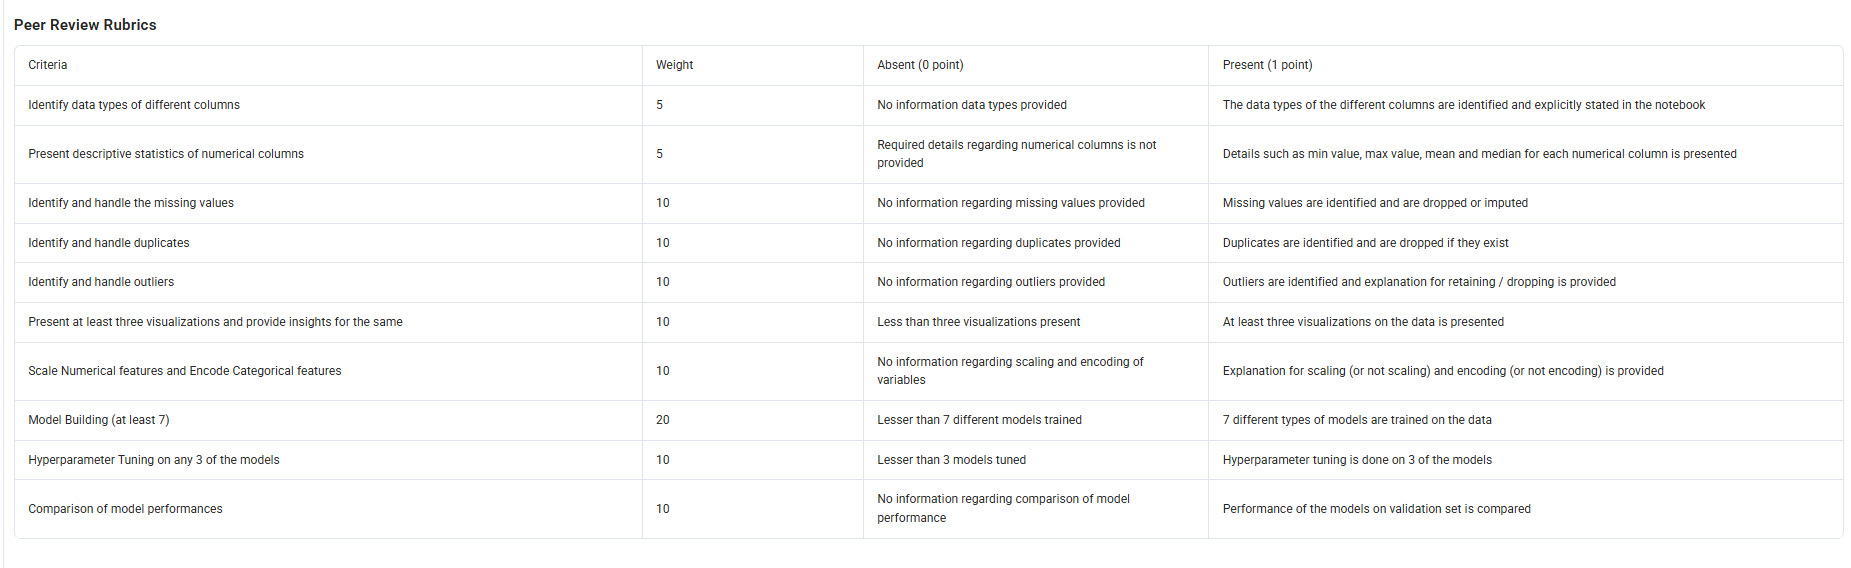

# DataSet Descriptions :
* **Files**
* train.csv - The training set which contains the features and the target
* test.csv - The test set for which the target column is hidden
* sample_submission.csv - A sample submission file in the correct format
* 

* **Column Description**
1. **airline**: Name of the Airline company
2. **flight**: Information about flight code
3. **source**: City from which the flight takes off
4. **departure**: Time period at which the flight takes off
5. **stops**: Number of stops between source and destination cities
6. **arrival**: time period at which the flight lands
7. **destination**: City where the flight lands
8. **class**: Information about seat class
9. **duration**: Overall time taken to travel between cities in hours
10. **days_left**: Number of days between booking and trip dates
11. **price**: Information about ticket price

# Dataset Loading

**Importing Libraries which are important for now**

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [14]:
#Train and Test dataset
train_data=pd.read_csv("/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/train.csv")
test_data=pd.read_csv("/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/test.csv")

In [15]:
train_data

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584
...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39995,Vistara,UK-940,Mumbai,NaN,one,Evening,Bangalore,Economy,21.25,43.0,6450
39996,39996,Vistara,UK-720,Kolkata,Early_Morning,one,Night,Mumbai,Business,14.08,12.0,64831
39997,39997,NaN,UK-874,Hyderabad,Morning,one,Night,Bangalore,Economy,14.33,NaN,8062
39998,39998,Vistara,UK-940,Mumbai,NaN,one,Night,Bangalore,Business,24.67,4.0,84557


In [16]:
test_data

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left
0,0,Vistara,UK-816,Bangalore,Morning,zero,Afternoon,Delhi,Economy,2.67,18.0
1,1,Air_India,AI-440,Chennai,Early_Morning,zero,Morning,Delhi,Economy,NaN,5.0
2,2,SpiceJet,SG-8938,Delhi,Evening,one,Evening,Bangalore,Economy,NaN,44.0
3,3,Vistara,UK-838,Chennai,Night,one,Evening,Kolkata,Business,21.00,26.0
4,4,Air_India,AI-429,Delhi,Morning,one,Evening,Mumbai,Business,7.25,22.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,Air_India,AI-839,Delhi,Night,one,Early_Morning,Chennai,Economy,10.58,23.0
9996,9996,Air_India,AI-663,Mumbai,Afternoon,one,Night,Hyderabad,Economy,7.67,NaN
9997,9997,Vistara,UK-836,Chennai,Morning,one,Night,Hyderabad,Business,10.17,24.0
9998,9998,Air_India,AI-541,Hyderabad,Evening,one,Morning,Bangalore,Business,16.67,49.0


In [17]:
train_data.shape

(40000, 12)

In [18]:
test_data.shape

(10000, 11)

# 1. Data Understanding — Structure & Data Types

In [19]:
print("Shape of Training Data is :",train_data.shape)
print("Printing the information about the Training Dataset ---> ")
print()
train_data.info()

Shape of Training Data is : (40000, 12)
Printing the information about the Training Dataset ---> 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    35208 non-null  object 
 5   stops        37681 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB


1. **Categorical Features :** Airline, Flight, Source, Departure, Stops, Arrival, Destination, Class
2. **Numerical Features :** id, Duration, Days_Left, Price

In [20]:
print("Categorical Features are : ",train_data.select_dtypes(include="object").columns.tolist())
print()
print("Numerical Features are : ",train_data.select_dtypes(include="number").columns.tolist())

Categorical Features are :  ['airline', 'flight', 'source', 'departure', 'stops', 'arrival', 'destination', 'class']

Numerical Features are :  ['id', 'duration', 'days_left', 'price']


# NOTE:
We have Few Columns which are not important for us and Others Detailings :
**Like**
1. **id** : ID column is  only a indenntifier it  will not conclude anything  in our  dataset so we can easily drop it out in our further Steps
2. **Price :** Price column is a TARGET column so we seprate it out from out training dataset to make it as a Label Data
3. **Nomianl Columns :** airline, flight, source, destination
4. **Ordinal Columns :** stops, departure, arrival, class,
5. **Numeric Continous :** duration, days_left

**ORDINAL COLUMNS**
1. Stops : 0 < 1 < 2 < 3 < ........
2. Departure : Early_ morning, morining -> noon -> after-noon -> evening -> night -> ....
3. arrival : Early_ morning, morining -> noon -> after-noon -> evening -> night -> ....
4. class : Economy < business 

* Ordinal columns → can use **OrdinalEncoder** with a defined order
* Nominal columns → need OneHotEncoder, never plain integer encoding 

# 2. Descriptive analysis

In [21]:
train_data.describe()

,id,duration,days_left,price
count,40000.00000,36987.000000,35562.000000,40000.00000
mean,19999.50000,12.004088,26.197936,20801.49025
std,11547.14972,7.108063,13.469232,22729.14842
min,0.00000,0.830000,1.000000,1105.00000
25%,9999.75000,6.670000,15.000000,4687.00000
50%,19999.50000,11.080000,26.000000,7353.00000
75%,29999.25000,15.920000,38.000000,42521.00000
max,39999.00000,47.080000,49.000000,114704.00000


* From here we can see that there are **Missing Values** in these(duration, days_left) Columns. Because there is Dataset shape is 40000 but the count is differ from these columns count
* Also from code
* train_data.info() there is all the columns mention which have null values

* mean vs median
* This pair is the single most important comparison in descriptive stats. Here's why:

* Mean is pulled toward extreme values (sensitive to outliers)
* Median is robust — it just cares about the middle value regardless of how extreme the tails are

* **Right Skewed :** If mean > median
* **Left SKewed :** If mean < median
* **Symmetric :** If mean ==  median

**NOTE :**
* **Price:** The target Column "price" , mean > median so we can say that this column is  right skewwed so we can say that the ticket price of few of the flights are high costs.
* **duration:** duration column also seems to be little rightly skewed beacuse mean is slightly higher than the median and also the max is bit higher the 75 %
*  **days_left:** days_left column is loooking uniformally symmetric because the mean is looking similiar to the median 

**MISSING VALUES**
1. duration : Total=40000
    *        Count=36987.000000
    *        Total - Counnt = 40000-36987 = 3013 => (3013 / 40000) * 100 = 7.53%
2. days_left :
    *        Total = 40000
    *        Count = 35562
    *        Total -  Count = 40000 - 35562 = 4438 => (4438 / 40000) * 100 = 11.09%  

We have to Commpute these  missing values of Numerical columns because we can not  ignore or drop these feww columns because  these percentage of missing values are computables 

In [22]:
40000-36987

3013

In [23]:
(3013 / 40000) * 100


7.532500000000001

In [24]:
40000 - 35562

4438

In [25]:
(4438 / 40000) * 100 

11.094999999999999

# 3. Missing Values — Detection & Handling

In [26]:
train_data.isna().sum()

id                0
airline        4613
flight            0
source            0
departure      4792
stops          2319
arrival           0
destination       0
class             0
duration       3013
days_left      4438
price             0
dtype: int64

From here we can clearly sees that which ccolumns have missing values in it
* airline : 4613
* deaprture : 4792
* stops : 2319
* duration : 3013
* days_left : 4438

In [27]:
#Missing Percentages
missing = train_data.isna().sum()
missing_percentage = (missing / train_data.shape[0]) * 100
missing_percentage

id              0.0000
airline        11.5325
flight          0.0000
source          0.0000
departure      11.9800
stops           5.7975
arrival         0.0000
destination     0.0000
class           0.0000
duration        7.5325
days_left      11.0950
price           0.0000
dtype: float64

In [28]:
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percentage})
missing_summary 

,Missing Count,Missing %
id,0,0.0000
airline,4613,11.5325
flight,0,0.0000
source,0,0.0000
departure,4792,11.9800
stops,2319,5.7975
arrival,0,0.0000
destination,0,0.0000
class,0,0.0000
duration,3013,7.5325


In [29]:
missing_summary[missing_summary['Missing Count'] > 0].sort_values(by="Missing %",ascending=False)

,Missing Count,Missing %
departure,4792,11.9800
airline,4613,11.5325
days_left,4438,11.0950
duration,3013,7.5325
stops,2319,5.7975


All these of the columns must be **IMPUTE** because the percentage of the missing values in these columns are not that high which we can ignore out so we have to handle the missing values in these columns 

# Pattern Visualisation

In [30]:
#importing the visualisation libbraries
import matplotlib.pyplot as plt
import seaborn as sns


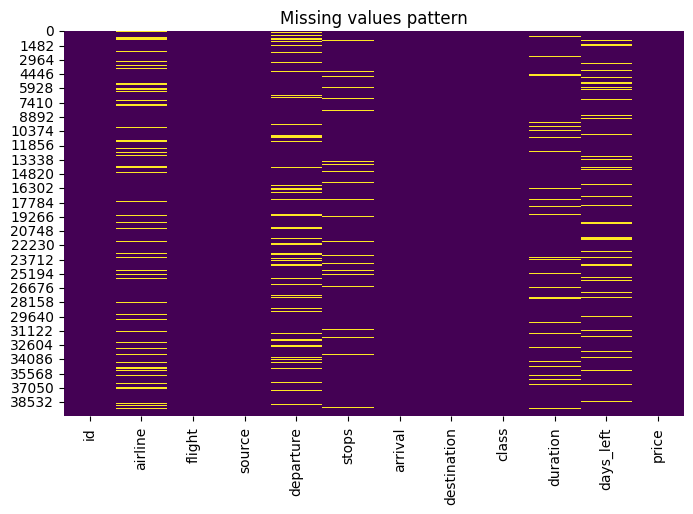

In [31]:
plt.figure(figsize=(8,5))
sns.heatmap(train_data.isna(),cbar=False,cmap='viridis')
plt.title("Missing values pattern")
plt.show()

**Checking missingness INSIGHTS**
* Missing Completely At Random
* Missing At Random
* Missing Not At Random

In [32]:
train_data["duration_missing"]=train_data["duration"].isna()
train_data.groupby('airline')["duration_missing"].mean().sort_values()

airline
SpiceJet     0.069810
Air_India    0.073845
AirAsia      0.074566
GO_FIRST     0.075223
Vistara      0.075749
Indigo       0.079641
Name: duration_missing, dtype: float64

In [33]:
train_data.groupby("class")["duration_missing"].mean().sort_values()

class
Business    0.072368
Economy     0.076663
Name: duration_missing, dtype: float64

In [34]:
train_columns=train_data.columns
train_columns

Index(['id', 'airline', 'flight', 'source', 'departure', 'stops', 'arrival',
       'destination', 'class', 'duration', 'days_left', 'price',
       'duration_missing'],
      dtype='object')

In [35]:
train_data["days_left_missing"]=train_data["days_left"].isna()

In [36]:
train_data

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price,duration_missing,days_left_missing
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173,True,False
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357,False,False
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251,False,False
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776,False,False
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39995,Vistara,UK-940,Mumbai,NaN,one,Evening,Bangalore,Economy,21.25,43.0,6450,False,False
39996,39996,Vistara,UK-720,Kolkata,Early_Morning,one,Night,Mumbai,Business,14.08,12.0,64831,False,False
39997,39997,NaN,UK-874,Hyderabad,Morning,one,Night,Bangalore,Economy,14.33,NaN,8062,False,True
39998,39998,Vistara,UK-940,Mumbai,NaN,one,Night,Bangalore,Business,24.67,4.0,84557,False,False


In [37]:
train_data.groupby("airline")["days_left_missing"].mean().sort_values()

airline
SpiceJet     0.099728
Indigo       0.107143
GO_FIRST     0.109091
Vistara      0.109407
AirAsia      0.109806
Air_India    0.115810
Name: days_left_missing, dtype: float64

In [38]:
train_data.groupby("class")["days_left_missing"].mean().sort_values()

class
Economy     0.109021
Business    0.115212
Name: days_left_missing, dtype: float64

In [39]:
train_data.groupby("source")["days_left_missing"].mean().sort_values()

source
Kolkata      0.108139
Hyderabad    0.109272
Delhi        0.109781
Chennai      0.110916
Bangalore    0.113142
Mumbai       0.113527
Name: days_left_missing, dtype: float64

In [40]:
train_data.groupby("destination")["days_left_missing"].mean().sort_values()

destination
Chennai      0.103455
Mumbai       0.106892
Delhi        0.109772
Hyderabad    0.113377
Kolkata      0.113536
Bangalore    0.118431
Name: days_left_missing, dtype: float64

**NOTE**
From this obervation of missing columns with compare with the other columns we can now  say that these columns are not dependent on other columns for being as missed  -----> so we impute these by taking in our mind that these are **MCAR** by using of mean/median

# Imputation

In [41]:
train_data["duration"]=train_data["duration"].fillna(train_data["duration"].median())
train_data["days_left"]=train_data["days_left"].fillna(train_data["days_left"].median())

In [42]:
train_data

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price,duration_missing,days_left_missing
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,11.08,40.0,64173,True,False
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357,False,False
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251,False,False
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776,False,False
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39995,Vistara,UK-940,Mumbai,NaN,one,Evening,Bangalore,Economy,21.25,43.0,6450,False,False
39996,39996,Vistara,UK-720,Kolkata,Early_Morning,one,Night,Mumbai,Business,14.08,12.0,64831,False,False
39997,39997,NaN,UK-874,Hyderabad,Morning,one,Night,Bangalore,Economy,14.33,26.0,8062,False,True
39998,39998,Vistara,UK-940,Mumbai,NaN,one,Night,Bangalore,Business,24.67,4.0,84557,False,False


**NOTE**
Since we check earlier that ["duration","days_left"] having a outlliers becuse there ( mean > median ) so they are rightly skewed so we can say easily imputing with the mean can be biased so good  thing is that we can impute it with the MEDIAN on the place of the mean---->

In [43]:
train_data.drop(columns=["duration_missing","days_left_missing"],inplace=True)

In [44]:
train_data.isna().sum()

id                0
airline        4613
flight            0
source            0
departure      4792
stops          2319
arrival           0
destination       0
class             0
duration          0
days_left         0
price             0
dtype: int64

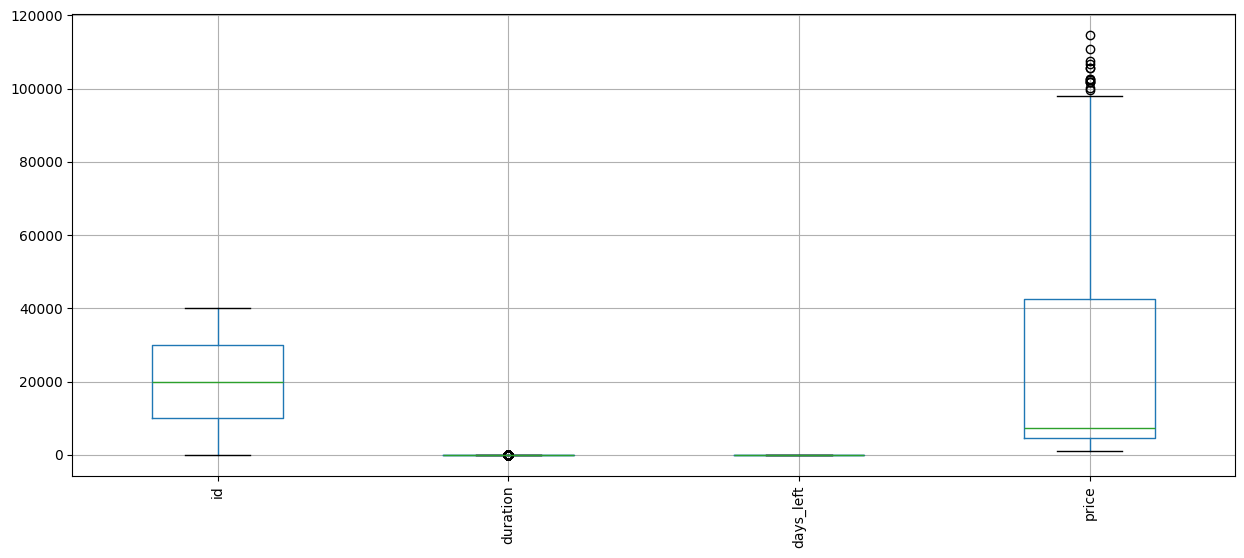

In [45]:
train_data.boxplot(figsize=(15,6), rot=90)
plt.show()

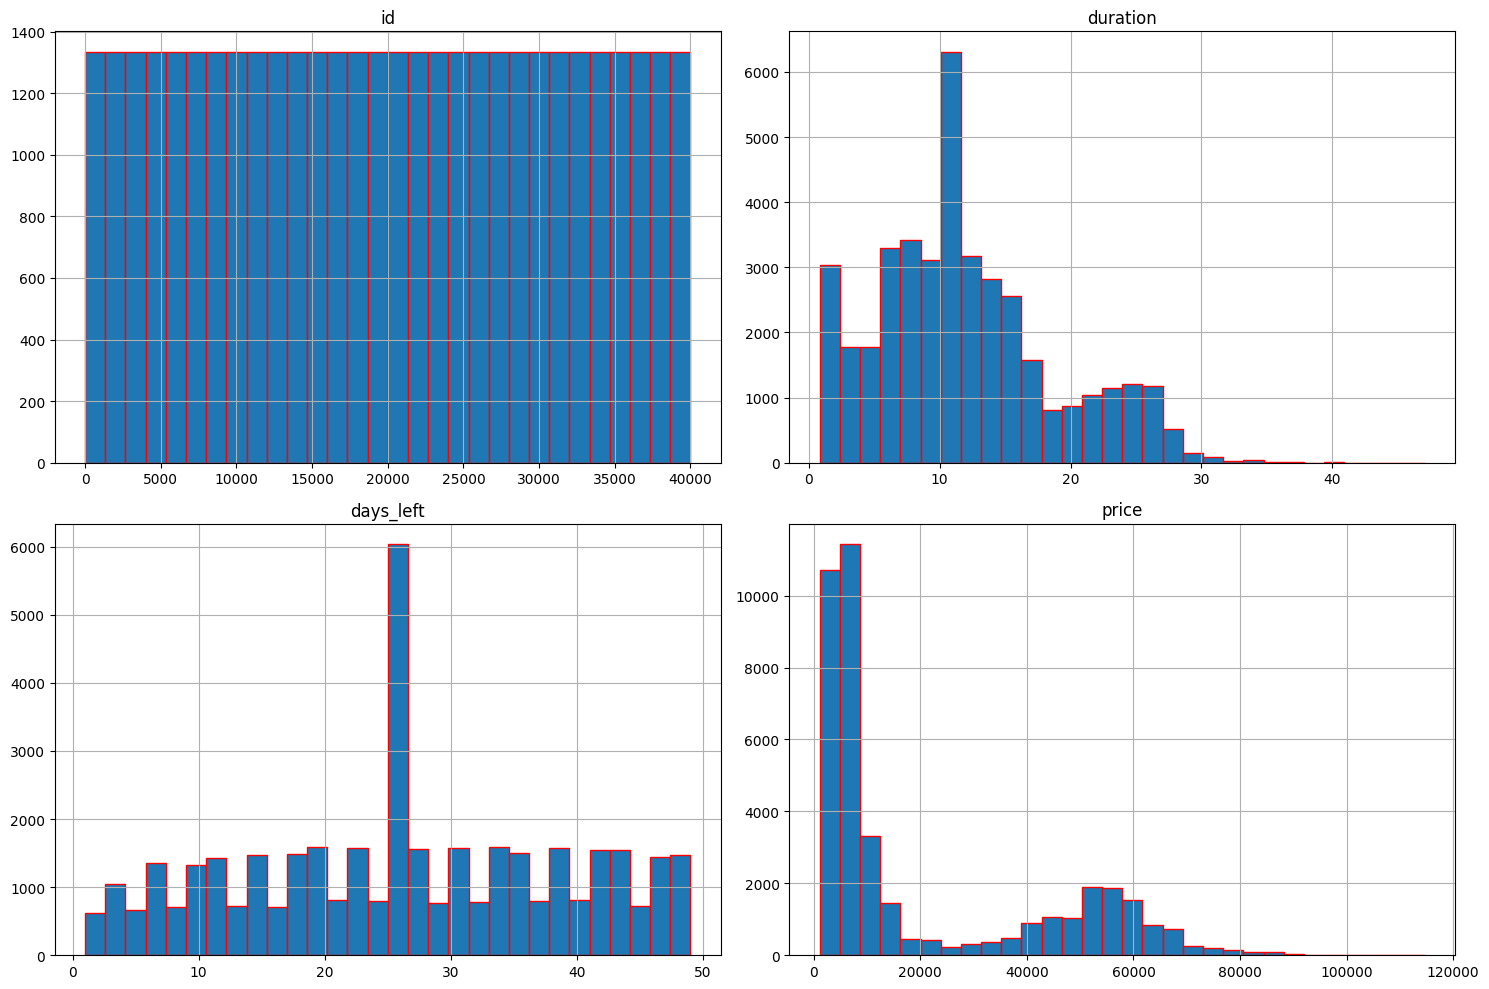

In [46]:
train_data.hist(
    bins=30,
    figsize=(15, 10),
    edgecolor='red'
)

plt.tight_layout()
plt.show()

We can clearly says that by seeing the histogram of the numerical columns of our datset that the Outliers are present the datset

In [47]:
train_data.isna().sum()

id                0
airline        4613
flight            0
source            0
departure      4792
stops          2319
arrival           0
destination       0
class             0
duration          0
days_left         0
price             0
dtype: int64

In [48]:
train_data['airline_missing'] = train_data['airline'].isnull()
train_data['departure_missing'] = train_data['departure'].isnull()
train_data['stops_missing'] = train_data['stops'].isnull()

print(train_data.groupby('class')['airline_missing'].mean())
print()
print(train_data.groupby('source')['airline_missing'].mean())
print()
print(train_data.groupby('destination')['airline_missing'].mean())

class
Business    0.115533
Economy     0.115231
Name: airline_missing, dtype: float64

source
Bangalore    0.111559
Chennai      0.122632
Delhi        0.113933
Hyderabad    0.114974
Kolkata      0.117218
Mumbai       0.114142
Name: airline_missing, dtype: float64

destination
Bangalore    0.114730
Chennai      0.114599
Delhi        0.116312
Hyderabad    0.119002
Kolkata      0.113078
Mumbai       0.114563
Name: airline_missing, dtype: float64


From here we can see that the missingness of the "airline" column is not dependent on any other columns so this can be impute through the MCAR by using mean/median or mode

In [49]:
print(train_data.groupby('class')['departure_missing'].mean())
print()
print(train_data.groupby('source')['departure_missing'].mean())
print()
print(train_data.groupby('destination')['departure_missing'].mean())

class
Business    0.118742
Economy     0.120279
Name: departure_missing, dtype: float64

source
Bangalore    0.119332
Chennai      0.115602
Delhi        0.118696
Hyderabad    0.125828
Kolkata      0.119488
Mumbai       0.120162
Name: departure_missing, dtype: float64

destination
Bangalore    0.119615
Chennai      0.127415
Delhi        0.119774
Hyderabad    0.114783
Kolkata      0.120250
Mumbai       0.118016
Name: departure_missing, dtype: float64


In [50]:
print(train_data.groupby('class')['stops_missing'].mean())
print()
print(train_data.groupby('source')['stops_missing'].mean())
print()
print(train_data.groupby('destination')['stops_missing'].mean())

class
Business    0.057847
Economy     0.058033
Name: stops_missing, dtype: float64

source
Bangalore    0.059018
Chennai      0.058387
Delhi        0.056295
Hyderabad    0.058131
Kolkata      0.058042
Mumbai       0.058361
Name: stops_missing, dtype: float64

destination
Bangalore    0.053590
Chennai      0.058507
Delhi        0.056296
Hyderabad    0.061874
Kolkata      0.060430
Mumbai       0.058177
Name: stops_missing, dtype: float64


In [51]:
print(train_data['airline'].value_counts())
print()
print(train_data['departure'].value_counts())
print()
print(train_data['stops'].value_counts())

airline
Vistara      15063
Air_India     9222
Indigo        5236
GO_FIRST      2805
AirAsia       1958
SpiceJet      1103
Name: count, dtype: int64

departure
Morning          8302
Early_Morning    7788
Evening          7709
Night            5690
Afternoon        5565
Late_Night        154
Name: count, dtype: int64

stops
one            31439
zero            4741
two_or_more     1501
Name: count, dtype: int64


**"stops imputed with mode due to strong class dominance (~83%); airline and departure imputed with an explicit 'Unknown' category since no single category held a clear majority, avoiding artificial distribution distortion."**

We impute categorical columns with mode if any values is highly contributing > 50% in a column

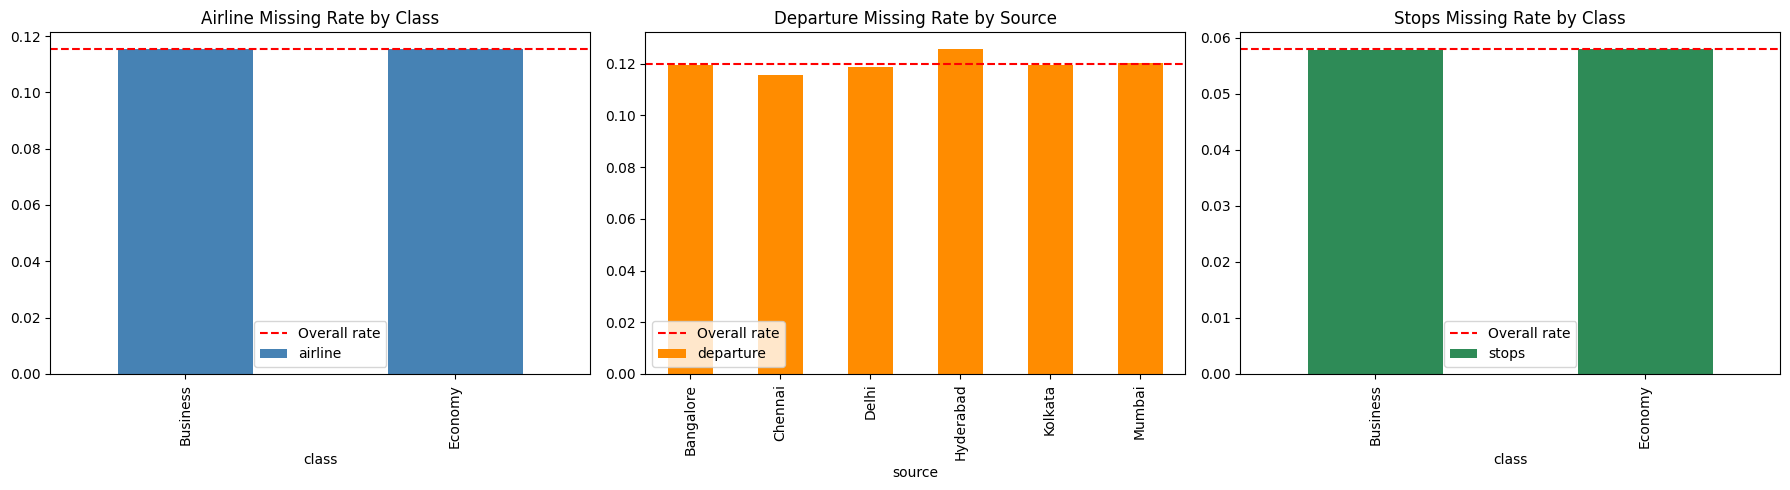

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

train_data.groupby('class')['airline'].apply(lambda x: x.isnull().mean()).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Airline Missing Rate by Class')
axes[0].axhline(train_data['airline'].isnull().mean(), color='red', linestyle='--', label='Overall rate')
axes[0].legend()

train_data.groupby('source')['departure'].apply(lambda x: x.isnull().mean()).plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Departure Missing Rate by Source')
axes[1].axhline(train_data['departure'].isnull().mean(), color='red', linestyle='--', label='Overall rate')
axes[1].legend()

train_data.groupby('class')['stops'].apply(lambda x: x.isnull().mean()).plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Stops Missing Rate by Class')
axes[2].axhline(train_data['stops'].isnull().mean(), color='red', linestyle='--', label='Overall rate')
axes[2].legend()

plt.tight_layout()
plt.show()

In [53]:
train_data["airline"]=train_data["airline"].fillna("Unknown")
train_data["departure"]=train_data["departure"].fillna("Unknown")


In [54]:
train_data["stops"]=train_data["stops"].fillna(train_data["stops"].mode()[0])

In [55]:
train_data.drop(columns=["airline_missing","departure_missing","stops_missing"],inplace=True)
train_data

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,11.08,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,Unknown,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584
...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39995,Vistara,UK-940,Mumbai,Unknown,one,Evening,Bangalore,Economy,21.25,43.0,6450
39996,39996,Vistara,UK-720,Kolkata,Early_Morning,one,Night,Mumbai,Business,14.08,12.0,64831
39997,39997,Unknown,UK-874,Hyderabad,Morning,one,Night,Bangalore,Economy,14.33,26.0,8062
39998,39998,Vistara,UK-940,Mumbai,Unknown,one,Night,Bangalore,Business,24.67,4.0,84557


In [56]:
train_data.isna().sum()

id             0
airline        0
flight         0
source         0
departure      0
stops          0
arrival        0
destination    0
class          0
duration       0
days_left      0
price          0
dtype: int64

# 4. Duplicates

In [57]:
duplicate_count=train_data.duplicated().sum()
duplicate_count

np.int64(0)

**NOTE**
* No duplicate rows were found in the dataset (`duplicated().sum() = 0`). Since every row is unique, no rows were dropped, and the dataset shape remains unchanged from the missing-value handling step.

# 5. Outlier Detection & Handling

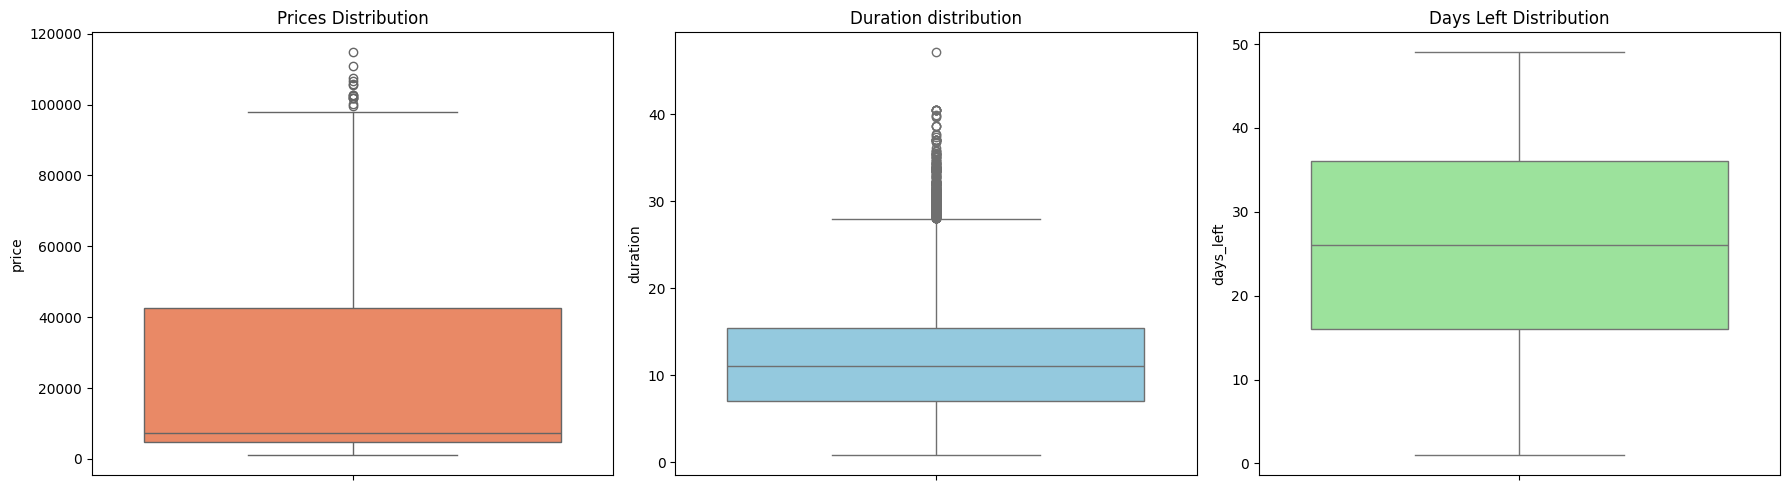

In [58]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
sns.boxplot(y=train_data["price"],ax=axes[0],color="coral")
axes[0].set_title("Prices Distribution")

sns.boxplot(y=train_data["duration"],ax=axes[1],color="skyblue")
axes[1].set_title("Duration distribution")

sns.boxplot(y=train_data["days_left"],ax=axes[2],color="lightgreen")
axes[2].set_title("Days Left Distribution")

plt.tight_layout()
plt.show()

In [59]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

    return outliers


price_outliers = detect_outliers_iqr(train_data, "price")
duration_outliers = detect_outliers_iqr(train_data, "duration")
days_left_outliers = detect_outliers_iqr(train_data, "days_left")

price: 14 outliers (0.03%)
duration: 470 outliers (1.18%)
days_left: 0 outliers (0.00%)


In [60]:
price_outliers

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
3025,3025,Vistara,UK-996,Mumbai,Evening,one,Night,Bangalore,Business,28.17,2.0,105764
4123,4123,Vistara,UK-776,Kolkata,Unknown,one,Afternoon,Delhi,Business,20.58,3.0,101780
10056,10056,Vistara,UK-910,Mumbai,Evening,one,Morning,Chennai,Business,16.33,7.0,100204
10688,10688,Vistara,UK-772,Kolkata,Morning,one,Night,Delhi,Business,11.17,17.0,101780
12077,12077,Vistara,UK-772,Kolkata,Morning,one,Evening,Hyderabad,Business,9.50,4.0,106753
13000,13000,Vistara,UK-706,Kolkata,Unknown,two_or_more,Night,Mumbai,Business,10.00,4.0,110936
15928,15928,Unknown,UK-772,Kolkata,Morning,one,Night,Delhi,Business,13.33,5.0,102648
20894,20894,Vistara,UK-832,Chennai,Unknown,one,Night,Mumbai,Business,15.08,5.0,114704
20931,20931,Vistara,UK-836,Chennai,Morning,one,Evening,Bangalore,Business,6.25,3.0,107597
24173,24173,Vistara,UK-910,Mumbai,Evening,one,Evening,Bangalore,Business,25.25,26.0,102404


In [61]:
duration_outliers

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
73,73,Vistara,UK-706,Kolkata,Morning,two_or_more,Evening,Chennai,Economy,33.67,26.0,18425
141,141,Air_India,AI-672,Chennai,Afternoon,one,Night,Delhi,Economy,33.00,27.0,6466
162,162,Air_India,AI-429,Chennai,Afternoon,two_or_more,Evening,Bangalore,Economy,29.17,26.0,13128
239,239,Vistara,UK-813,Delhi,Unknown,one,Night,Mumbai,Economy,28.25,26.0,14093
342,342,Air_India,AI-764,Delhi,Unknown,one,Night,Hyderabad,Economy,28.33,34.0,3994
...,...,...,...,...,...,...,...,...,...,...,...,...
39415,39415,Air_India,AI-809,Mumbai,Unknown,one,Evening,Hyderabad,Economy,31.58,15.0,10747
39795,39795,Air_India,AI-766,Chennai,Morning,one,Evening,Mumbai,Economy,30.08,30.0,8867
39800,39800,Air_India,AI-440,Chennai,Early_Morning,one,Night,Mumbai,Economy,38.58,16.0,8613
39827,39827,Air_India,AI-672,Chennai,Afternoon,one,Night,Delhi,Economy,30.00,31.0,7463


In [62]:
days_left_outliers

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price


In [63]:
price_outliers["class"].value_counts()

class
Business    14
Name: count, dtype: int64

In [64]:
duration_outliers["stops"].value_counts()

stops
one            373
two_or_more     97
Name: count, dtype: int64

**Outlier analysis via IQR reveals very few outliers overall. All 14 price outliers correspond to Business class fares, and all 470 duration outliers correspond to flights with one or more stops — both are physically legitimate values, not data errors. No implausible values (near-zero duration or price) were found either. Therefore, no outliers were removed; they represent real variation in the data (Business-class pricing and layover-driven duration) and will be handled implicitly through model choice — tree-based models are naturally robust to this, while a log-transformation of price will be considered for linear models**

#  6. Exploratory Data Analysis
* Structure: 
* 6.1 Univariate — Numeric features
* 6.2 Univariate — Categorical features  
* 6.3 Bivariate — Target vs Categorical features
* 6.4 Bivariate — Target vs Numeric features
* 6.5 Statistical Testing — Categorical relationships
* 6.6 Route-level Analysis
* 6.7 Multivariate — Correlation & Pairplot
* 6.8 EDA Summary & Feature Priority

**6.1 Univariate Analysis — Numeric Features**

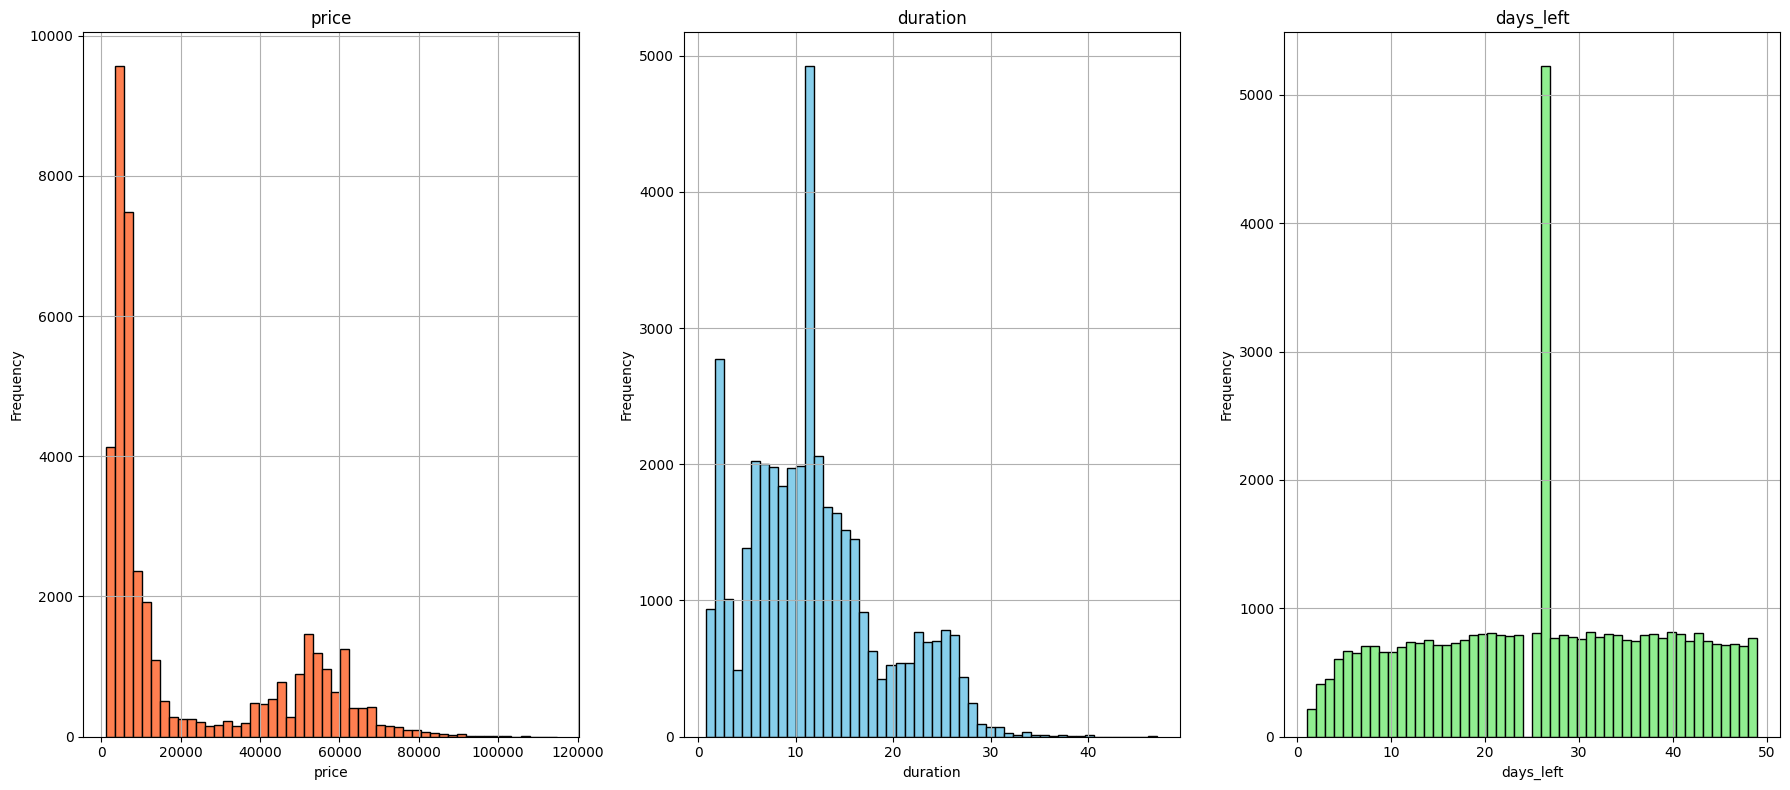

In [65]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

colors = ['coral', 'skyblue', 'lightgreen']
# numerical_columns=train_data.select_dtypes(include="number").columns
numerical_columns=['price','duration','days_left']
for i, col in enumerate(numerical_columns):
    train_data[col].hist(
        bins=50,
        ax=axes[i],
        color=colors[i],
        edgecolor='black'
    )

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

* We can see that few spikes in price and right skewed
* we can similiarly sees the some spikes in the duration and right skewed

In [66]:
from scipy.stats import skew,kurtosis
for col in ['price','duration','days_left']:
    print(f"{col} : skew={skew(train_data[col]):.2f}, kurtosis={kurtosis(train_data[col]):.2f}")

price : skew=1.06, kurtosis=-0.40
duration : skew=0.66, kurtosis=-0.02
days_left : skew=-0.05, kurtosis=-0.91


* skew = 0 -->Symmetric
* skew > 1 --->Stongly right skewed
* skew < 0 --> Left Skewed

  

**Log transformation on the price column**

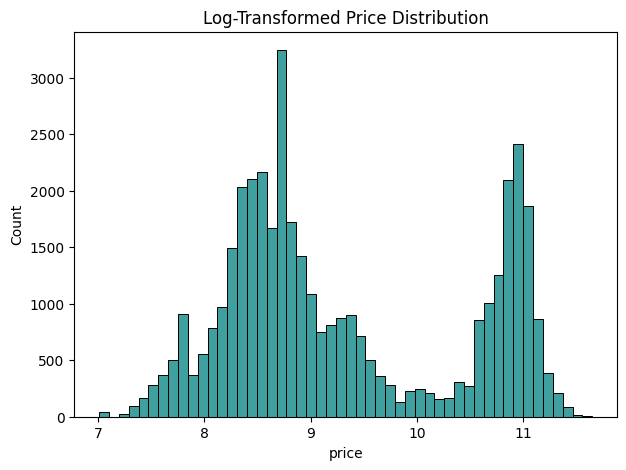

Log price skew: 0.41


In [67]:
plt.figure(figsize=(7,5))
sns.histplot(np.log1p(train_data['price']),bins=50,color='teal')
plt.title('Log-Transformed Price Distribution')
plt.show()
print(f"Log price skew: {skew(np.log1p(train_data['price'])):.2f}")

From here we can see on Logarithmic the price column the Skewness of the column is decreased slighlty 

**6.2 Univariate Analysis — Categorical Features**

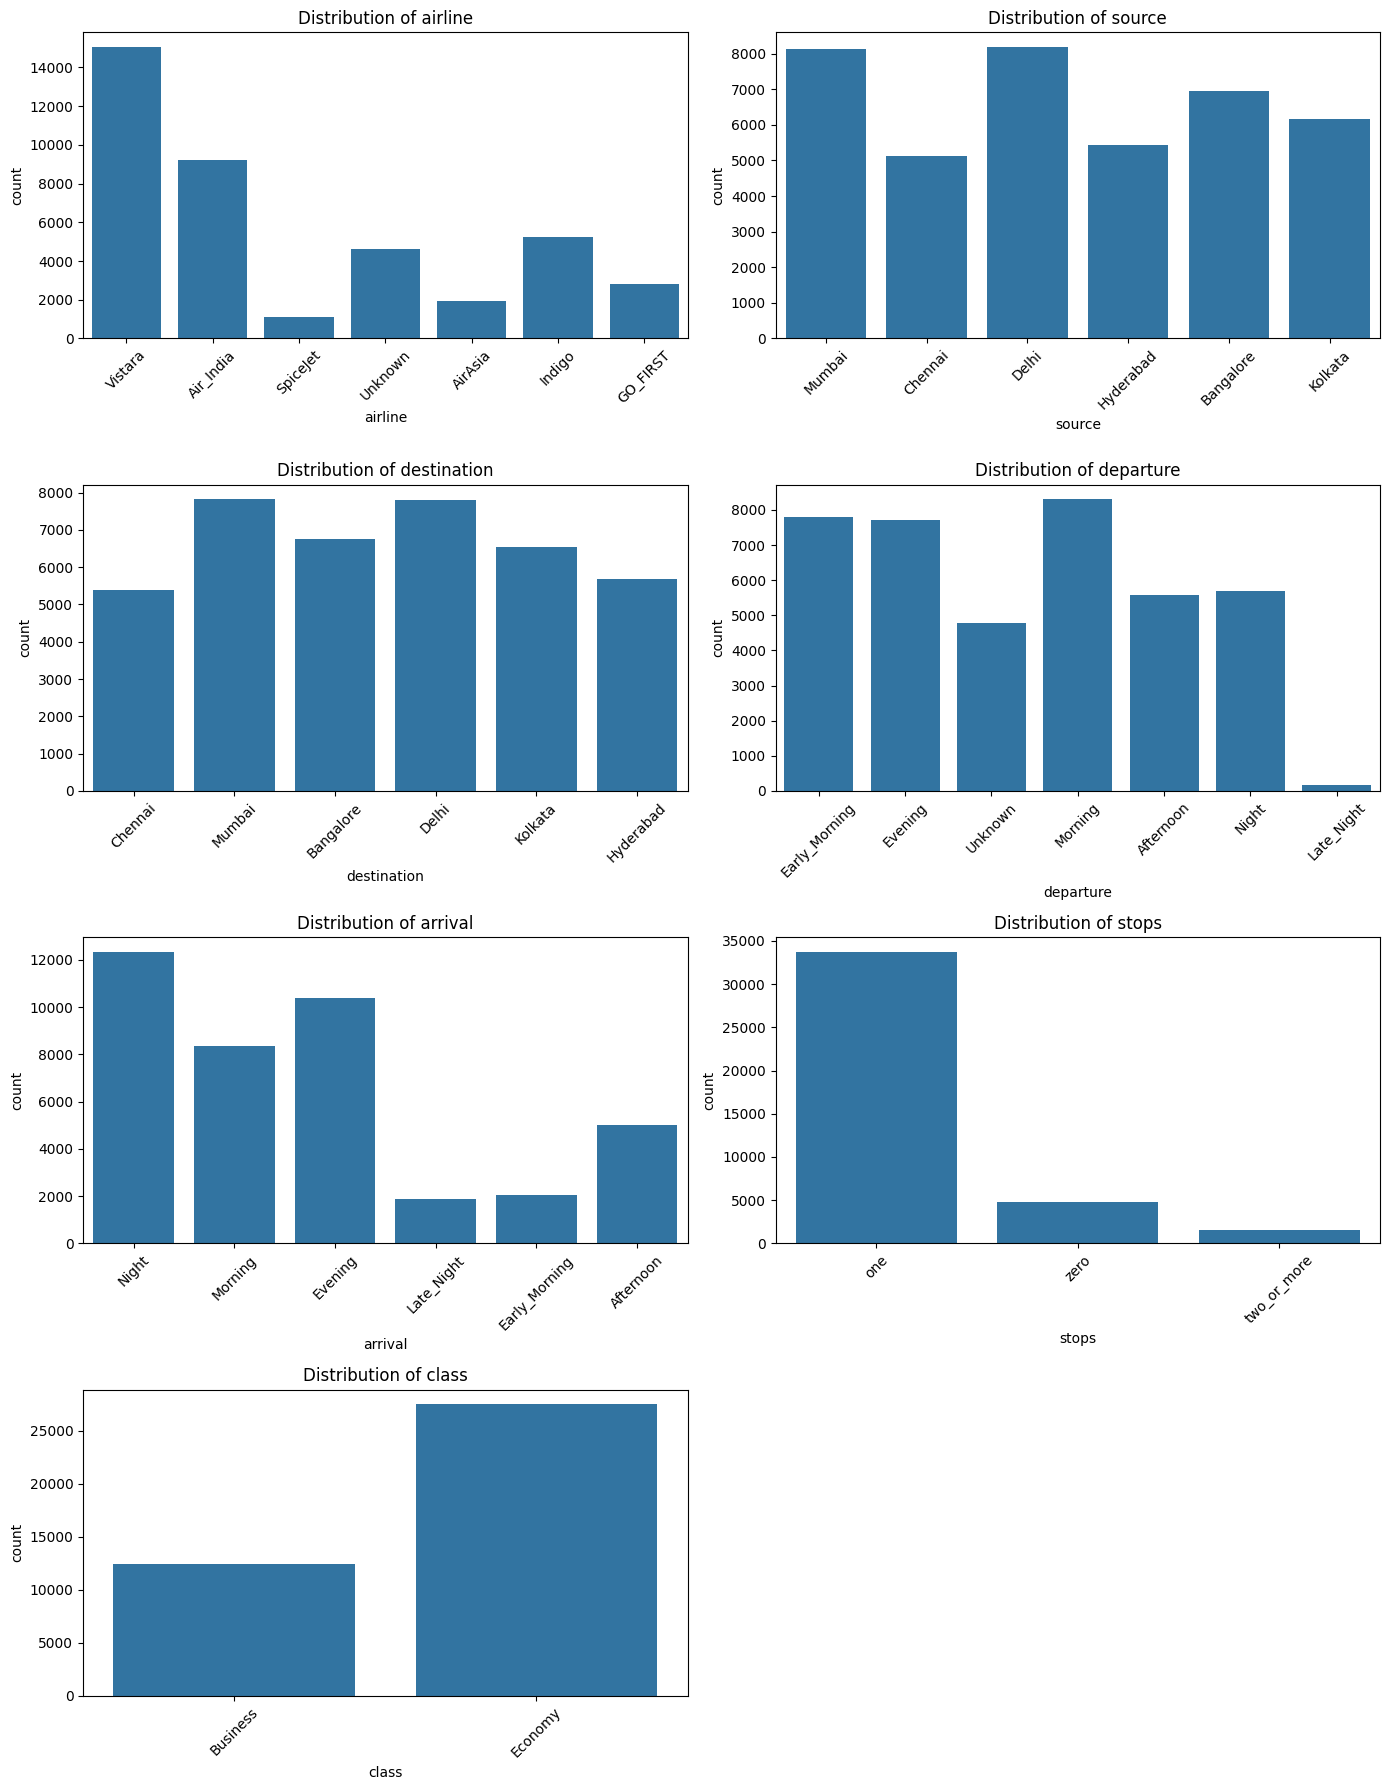

In [68]:
categorical_features=['airline', 'source', 'destination', 'departure', 'arrival', 'stops', 'class']
fig,axes=plt.subplots(4,2,figsize=(14,18))
axes=axes.flatten()
for i,col  in enumerate(categorical_features):
    sns.countplot(train_data,x=col,ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


In [69]:
for col in categorical_features:
    rare_cat = train_data[col].value_counts(normalize=True)
    print(f"{col} — smallest category share: {rare_cat.min()*100:.2f}% ({rare_cat.idxmin()})")

airline — smallest category share: 2.76% (SpiceJet)
source — smallest category share: 12.80% (Chennai)
destination — smallest category share: 13.46% (Chennai)
departure — smallest category share: 0.39% (Late_Night)
arrival — smallest category share: 4.71% (Late_Night)
stops — smallest category share: 3.75% (two_or_more)
class — smallest category share: 31.16% (Business)


**6.3 Bivariate — Target (price) vs Categorical Features**

In [70]:
train_data.groupby('airline')['price'].median()

airline
AirAsia       3201.0
Air_India    11627.0
GO_FIRST      5292.0
Indigo        4417.0
SpiceJet      5509.0
Unknown       7187.0
Vistara      15794.0
Name: price, dtype: float64

In [71]:
train_data.groupby('airline')['price'].median().sort_values(ascending=False)

airline
Vistara      15794.0
Air_India    11627.0
Unknown       7187.0
SpiceJet      5509.0
GO_FIRST      5292.0
Indigo        4417.0
AirAsia       3201.0
Name: price, dtype: float64

In [72]:
train_data.groupby('airline')['price'].median().sort_values(ascending=False).index

Index(['Vistara', 'Air_India', 'Unknown', 'SpiceJet', 'GO_FIRST', 'Indigo',
       'AirAsia'],
      dtype='object', name='airline')

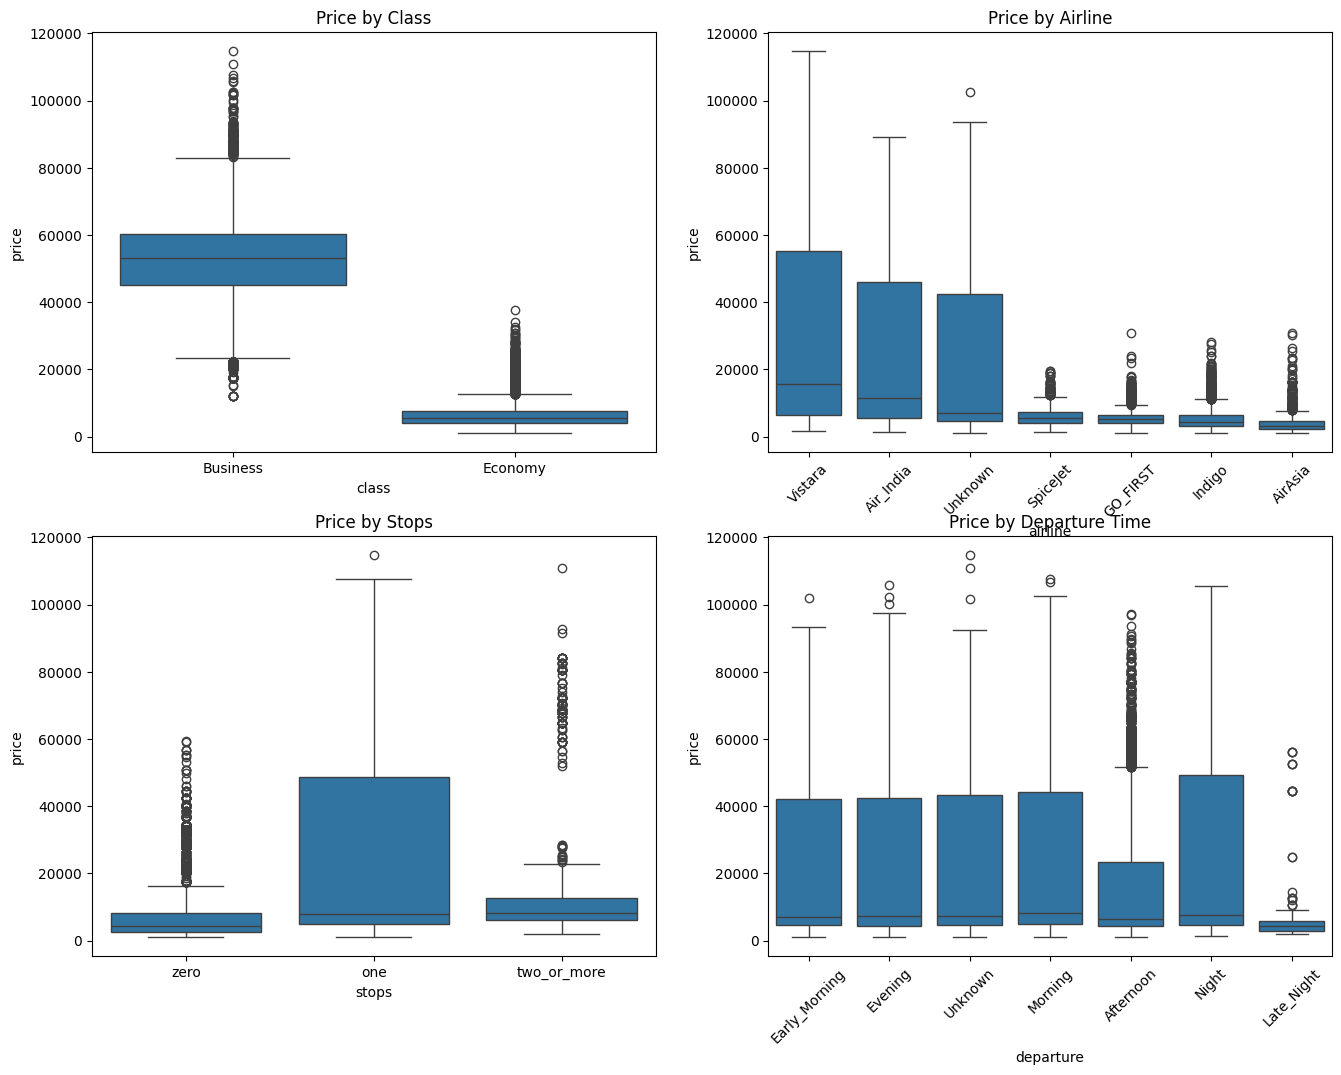

In [73]:
fig,axes=plt.subplots(2,2,figsize=(16,12))
sns.boxplot(data=train_data,x='class',y='price',ax=axes[0,0])
axes[0,0].set_title('Price by Class')

order_air=train_data.groupby('airline')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=train_data,x='airline',y='price',order=order_air,ax=axes[0,1])
axes[0,1].set_title('Price by Airline')
axes[0,1].tick_params(axis='x', rotation=45)


sns.boxplot(data=train_data, x='stops', y='price', order=['zero','one','two_or_more'], ax=axes[1,0])
axes[1,0].set_title('Price by Stops')


sns.boxplot(data=train_data, x='departure', y='price', ax=axes[1,1])
axes[1,1].set_title('Price by Departure Time')
axes[1,1].tick_params(axis='x', rotation=45)



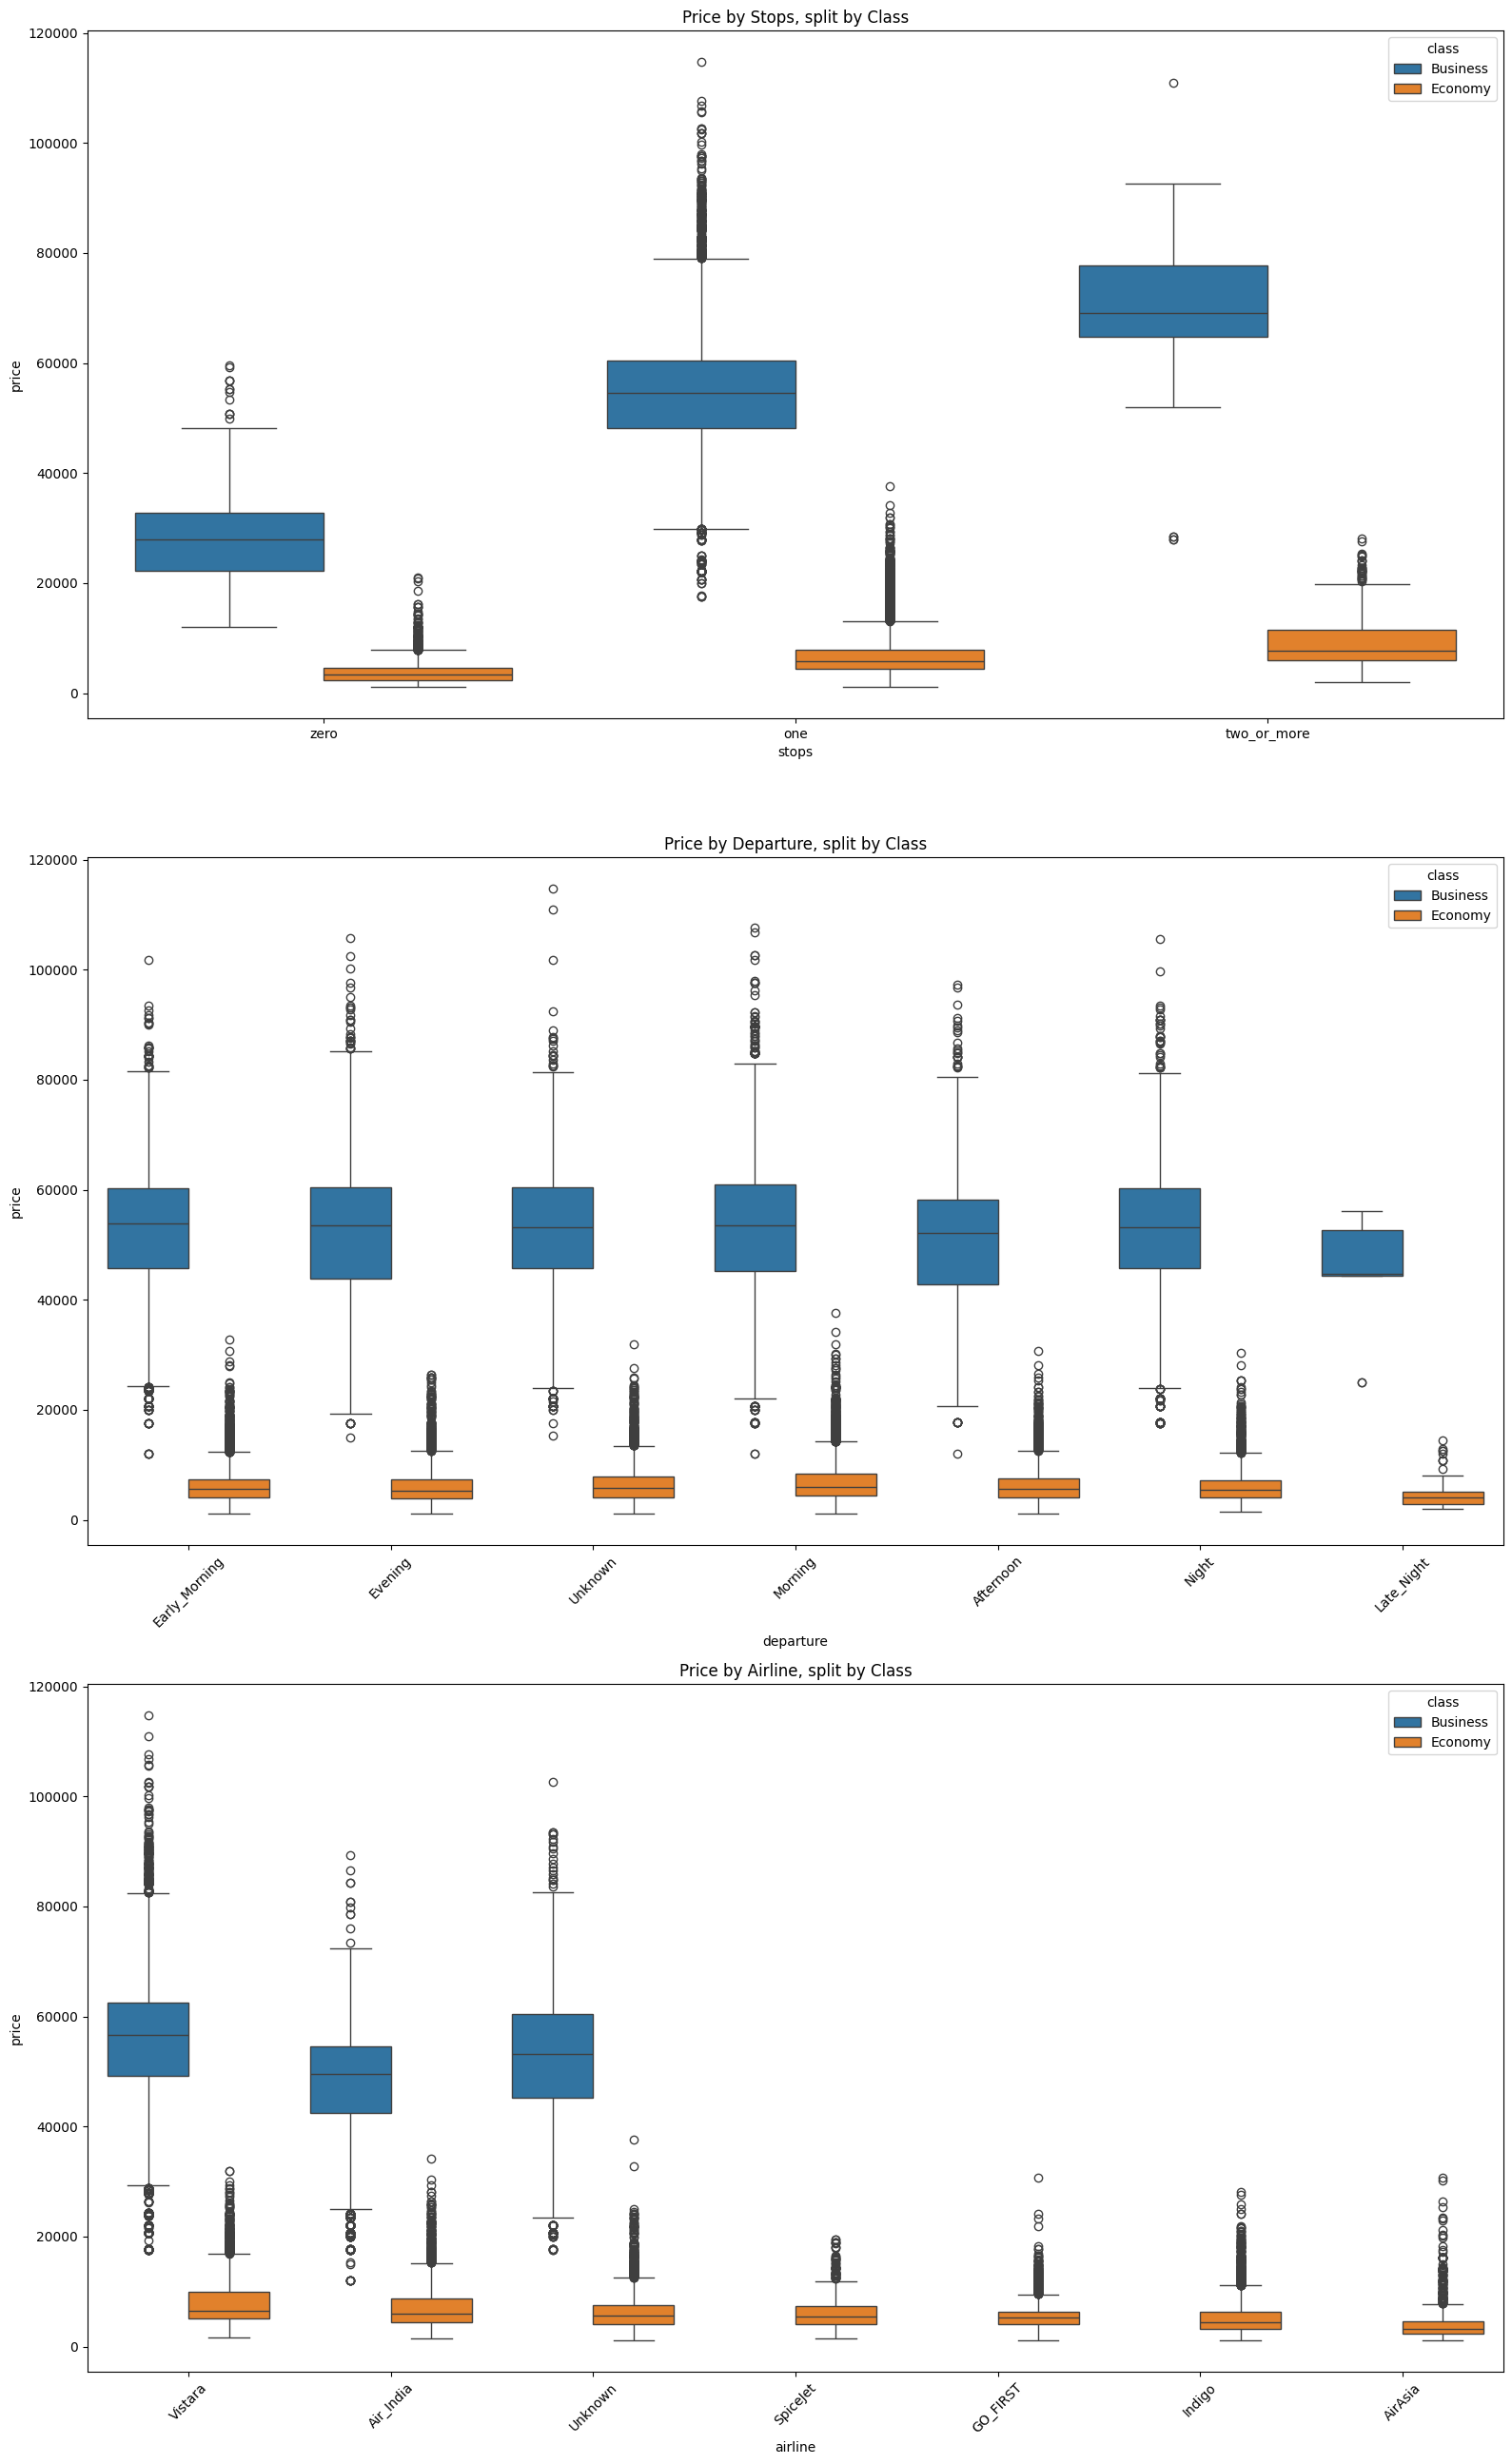

In [74]:
fig, axes = plt.subplots(3, 1, figsize=(16,26))
sns.boxplot(data=train_data, x='stops', y='price', hue='class', order=['zero','one','two_or_more'], ax=axes[0])
axes[0].set_title('Price by Stops, split by Class')

sns.boxplot(data=train_data, x='departure', y='price', hue='class', ax=axes[1])
axes[1].set_title('Price by Departure, split by Class')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=train_data, x='airline', y='price', hue='class',order=order_air, ax=axes[2])
axes[2].set_title('Price by Airline, split by Class')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**NOTE**
* More Stops have higher the prices
* departure time has little to no independent effect on price once class is controlled for
* Vistara, Air_India, and Unknown all show both a Business box and a substantial Economy box — they operate mixed fleets. SpiceJet, GO_FIRST, Indigo, AirAsia show only (or overwhelmingly) Economy boxes — essentially no Business presence. This explains the earlier "Vistara/Air_India look more expensive" pattern perfectly: it wasn't that those airlines charge more for the same service, it's that they're the only carriers offering Business class at all, which pulls their overall distribution up.
* Confounding checks confirm that Class is the primary driver of price and explains most of the variation initially attributed to Airline, Stops, and Departure Time individually. However, after controlling for Class, Stops still shows a real, independent monotonic effect (more stops -> higher price within each class), likely reflecting route complexity/distance. Departure Time shows negligible independent effect once Class is controlled. Airline's apparent effect is largely explained by which airlines operate Business class flights at all (Vistara, Air_India) versus Economy-only budget carriers.

**6.4 Bivariate — Target (price) vs Numeric Features**

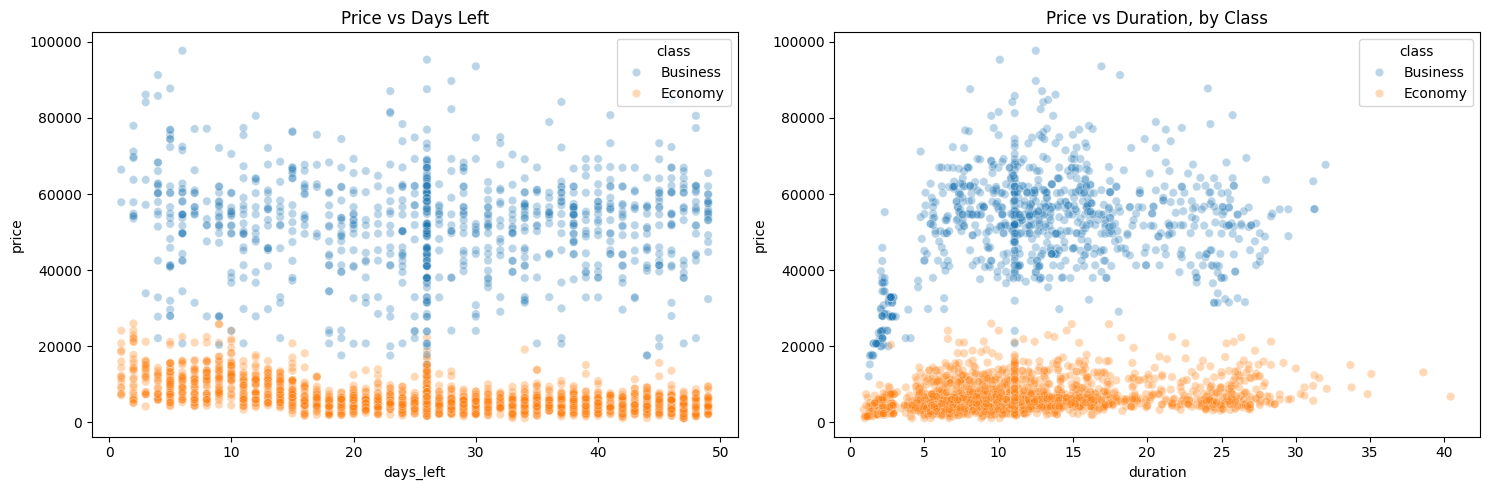

duration     0.208809
days_left   -0.088104
price        1.000000
Name: price, dtype: float64


In [75]:
sample = train_data.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.scatterplot(data=sample, x='days_left', y='price', alpha=0.3,hue=sample['class'], ax=axes[0])
axes[0].set_title('Price vs Days Left')

sns.scatterplot(data=sample, x='duration', y='price', alpha=0.3,hue=sample['class'], ax=axes[1])
axes[1].set_title('Price vs Duration, by Class')

plt.tight_layout()
plt.show()

print(train_data[['duration','days_left','price']].corr()['price'])

Both days_left and duration show weak linear correlation with price (0.21 and -0.09 respectively), suggesting neither has a strong straight-line relationship with price on its own. However, the scatterplots reveal the **real driver**: Business and Economy classes form two clearly separated bands regardless of days_left or duration — class dominates the price level, while duration and days_left cause only minor shifts within each band. Because correlation only measures linear relationships, we don't rule out these features yet — tree-based models can capture non-linear effects (e.g. last-minute booking spikes) that a correlation coefficient would miss.

**6.5 Statistical Testing — Categorical Relationships**

**Chi-square Test :**
* This pulls in a function that runs the Chi-Square Test of Independence — a formal statistical test for whether two categorical variables are related to each other, or behave independently.

In [76]:
from scipy.stats import chi2_contingency

def chi_square_test(df, col1, col2):
    ct = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(ct)
    print(f"{col1} vs {col2}: chi2={chi2:.2f}, p-value={p:.5f} -> {'Dependent' if p < 0.05 else 'Independent'}")

chi_square_test(train_data, 'source', 'airline')
chi_square_test(train_data, 'class', 'stops')
chi_square_test(train_data, 'departure', 'stops')

source vs airline: chi2=749.48, p-value=0.00000 -> Dependent
class vs stops: chi2=640.96, p-value=0.00000 -> Dependent
departure vs stops: chi2=416.01, p-value=0.00000 -> Dependent


"The Chi-Square Test of Independence is used to determine whether two categorical variables are statistically associated. It compares the observed frequencies in a contingency table with the expected frequencies under the assumption of independence. If the p-value is less than the chosen significance level (commonly 0.05), we conclude that the variables are associated (dependent); otherwise, we do not have enough evidence to conclude an association."

**6.6 Route-Level Analysis**
*  so far we've looked at source and destination as separate columns. But in real flight pricing, what actually matters is the combination — a **Mumbai-to-Chennai** flight and a **Mumbai-to-Delhi** flight can price very differently even though they share the same source. So we create a new combined feature called route just for this exploration

In [77]:
#Step 1 — Create the route column and see which routes are most common
train_data['route']=train_data['source'] + '-' + train_data['destination']
top_routes=train_data['route'].value_counts().head(10)
print(top_routes)

route
Delhi-Mumbai        2057
Mumbai-Delhi        2035
Bangalore-Delhi     1872
Delhi-Bangalore     1843
Mumbai-Bangalore    1717
Bangalore-Mumbai    1704
Mumbai-Kolkata      1674
Delhi-Kolkata       1594
Kolkata-Mumbai      1492
Delhi-Chennai       1432
Name: count, dtype: int64


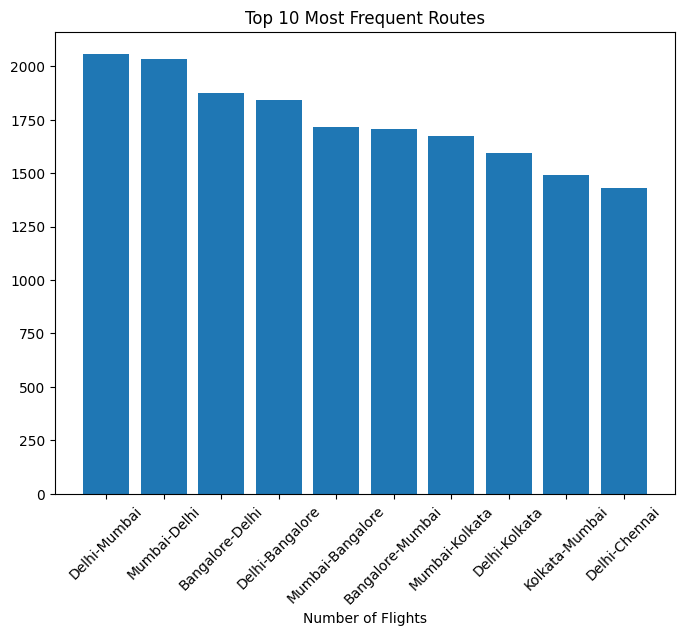

In [78]:
#visulization
plt.figure(figsize=(8,6))
plt.bar(top_routes.index,top_routes.values)
plt.xticks(rotation=45)
plt.title('Top 10 Most Frequent Routes')
plt.xlabel('Number of Flights')
plt.show()

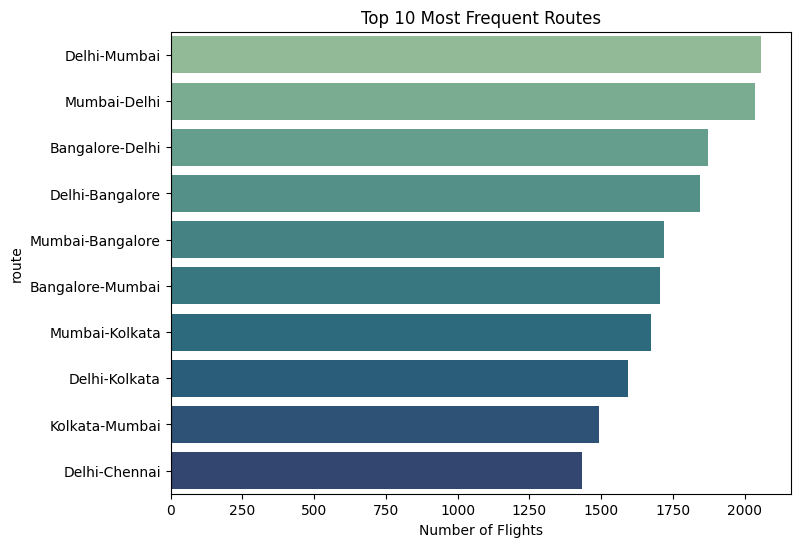

In [79]:
plt.figure(figsize=(8,6))
sns.barplot(x=top_routes.values, y=top_routes.index, palette='crest')
plt.title('Top 10 Most Frequent Routes')
plt.xlabel('Number of Flights')
plt.show()

In [80]:
route_price=train_data.groupby('route')['price'].mean().sort_values(ascending=False).head(10)
print(route_price)

route
Chennai-Bangalore    25687.973653
Kolkata-Chennai      24260.320527
Bangalore-Kolkata    23695.665678
Chennai-Kolkata      23563.802048
Mumbai-Chennai       23060.384615
Mumbai-Bangalore     23033.769948
Chennai-Mumbai       23003.522088
Bangalore-Mumbai     22823.296948
Bangalore-Chennai    22585.477791
Chennai-Hyderabad    22141.246609
Name: price, dtype: float64


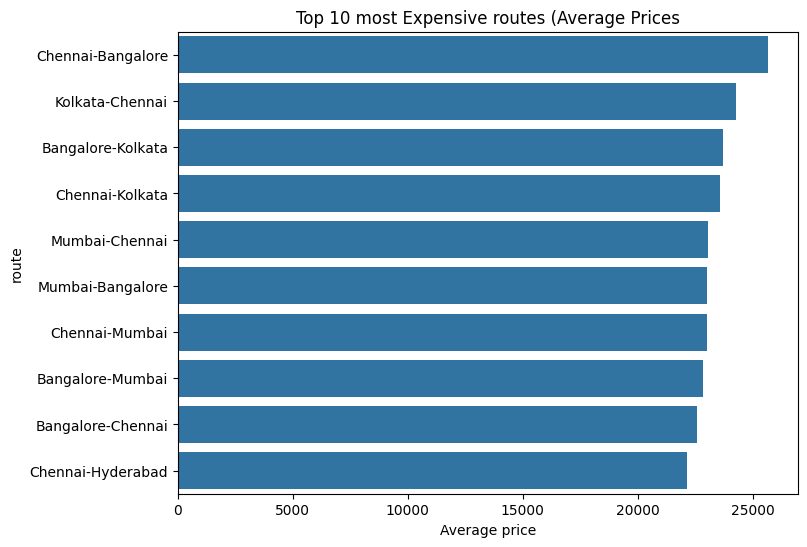

In [81]:
plt.figure(figsize=(8,6))
sns.barplot(x=route_price.values,y=route_price.index)
plt.title("Top 10 most Expensive routes (Average Prices")
plt.xlabel("Average price")
plt.show()

In [82]:
route_counts=train_data['route'].value_counts()
print(route_counts[route_price.index])

route
Chennai-Bangalore     835
Kolkata-Chennai       911
Bangalore-Kolkata    1349
Chennai-Kolkata       879
Mumbai-Chennai       1326
Mumbai-Bangalore     1717
Chennai-Mumbai       1245
Bangalore-Mumbai     1704
Bangalore-Chennai     833
Chennai-Hyderabad     811
Name: count, dtype: int64


* from here we can see that the **Chennai-based routes genuinely, reliably higher-priced hain — aur ye sirf 5-10 flights ka coincidence nahi, balki 800+ flights ke across consistent pattern hai.**
* Delhi wale routes (jo sabse frequent the) — woh sabse expensive list mein nahi aaye. Matlab: Delhi routes bahut common hain, lekin unka average price kaafi zyada nahi hai — probably kyunki woh short-haul, mostly Economy domestic routes hain.
* The most expensive routes (mostly involving Chennai) have substantial flight counts (800-1700+), confirming this is a genuine, reliable pricing pattern rather than a small-sample coincidence. Interestingly, the most frequent routes (mostly involving Delhi) do not overlap much with the most expensive ones — suggesting route popularity and route price are driven by different factors, likely related to distance and the proportion of Business class flights on each route.

**6.7 Correlation Heatmap & Pairplot**


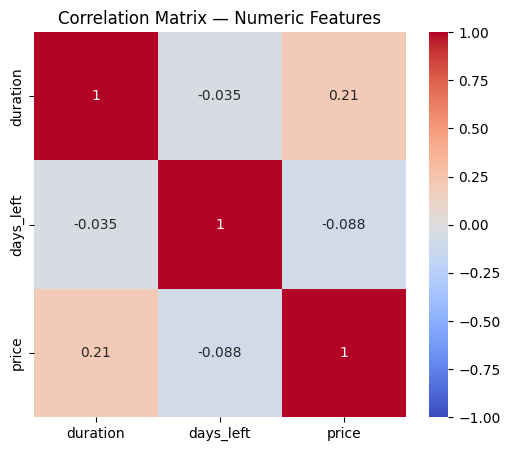

In [83]:
plt.figure(figsize=(6,5))
sns.heatmap(train_data[['duration','days_left','price']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numeric Features')
plt.show()

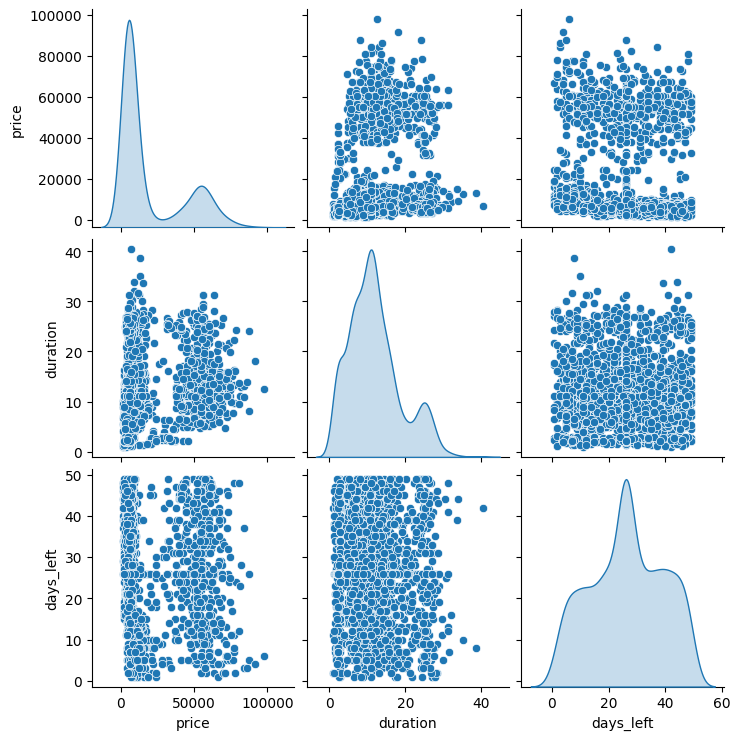

In [84]:
sns.pairplot(train_data.sample(2000, random_state=42)[['price','duration','days_left']], diag_kind='kde')
plt.show()

The correlation heatmap confirms only weak linear relationships between the numeric features and price. As established earlier, this doesn't mean these features are unimportant — it means their relationship with price (if any) is likely non-linear or mediated by class, which correlation alone cannot capture. The pairplot visually reinforces this, and highlights price's skewed/bimodal shape once more.

The pairplot confirms the bimodal shape of price (visible on the diagonal) and shows two separated clusters in price vs duration — consistent with the Economy/Business class split found earlier. No new numeric relationship emerges beyond what's already been established.

### EDA Summary

**Strongest predictor:** class — Business vs Economy creates a ~7x price gap and appears to dominate/confound nearly every other categorical relationship we examined (airline, stops, departure time).

**Secondary predictors (real, independent effects after controlling for class):**
- stops — more stops correlates with higher price within each class
- route — Chennai-based routes are reliably priced higher; Delhi routes are most frequent but not the most expensive

**Weak/negligible predictors:**
- departure time — no meaningful independent effect once class is controlled for
- days_left, duration — weak linear correlation, but nonlinear effects can't be ruled out; tree-based models may still extract value from them

**Statistical confirmation:** chi-square tests confirmed source-airline, class-stops, and departure-stops are all statistically dependent (p < 0.05), though with 40,000 rows this test is very sensitive, so effect size (seen in boxplots) matters more than significance alone.

**Data quality notes:** Late_Night departure is a rare category (~0.4% of data) — worth watching during encoding. No true duplicates found. Outliers in price/duration are legitimate (Business fares, multi-stop flights), not data errors.

**Implications for (Feature Engineering):**
- class is the top-priority feature — no engineering needed, just correct encoding
- route (source + destination) is worth engineering as an explicit feature
- Consider whether flight code, duration bucketing, or stop-count as numeric ordinal adds value
- log-transform price should be tested for linear models, based on skew evidence from 6.1

7. Feature Engineering


In [85]:
train_data['flight'].str.split('-')

0         [UK, 930]
1         [AI, 539]
2        [SG, 8107]
3        [0.00E+00]
4         [AI, 569]
            ...    
39995     [UK, 940]
39996     [UK, 720]
39997     [UK, 874]
39998     [UK, 940]
39999     [G8, 511]
Name: flight, Length: 40000, dtype: object

In [86]:
train_data.head(10)

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price,route
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,11.08,40.0,64173,Mumbai-Chennai
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357,Chennai-Mumbai
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251,Delhi-Chennai
3,3,Unknown,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776,Hyderabad-Bangalore
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584,Chennai-Bangalore
5,5,AirAsia,I5-620,Mumbai,Early_Morning,one,Morning,Delhi,Economy,6.17,26.0,2336,Mumbai-Delhi
6,6,SpiceJet,SG-3027,Bangalore,Unknown,one,Night,Kolkata,Economy,15.67,31.0,7553,Bangalore-Kolkata
7,7,Indigo,0.00E+00,Chennai,Evening,one,Night,Hyderabad,Economy,4.42,38.0,6880,Chennai-Hyderabad
8,8,Indigo,0.00E+00,Kolkata,Morning,one,Evening,Mumbai,Economy,4.67,35.0,6521,Kolkata-Mumbai
9,9,GO_FIRST,G8-1404,Delhi,Morning,one,Evening,Mumbai,Economy,7.08,28.0,4793,Delhi-Mumbai


In [87]:
train_data['flight'].value_counts()

flight
0.00E+00    5240
UK-706       448
UK-772       363
UK-720       348
UK-836       337
            ... 
SG-3725        1
SG-6005        1
AI-9809        1
SG-1090        1
I5-334         1
Name: count, Length: 869, dtype: int64

In [88]:
(train_data['flight'] == '0.00E+00').mean()*100

np.float64(13.100000000000001)

In [89]:
5240/40000

0.131

In [90]:
train_data['flight'] = train_data['flight'].replace('0.00E+00', np.nan)
print(train_data['flight'].isnull().sum())

5240


In [91]:
train_data['flight_code'] = train_data['flight'].str.split('-').str[0]
train_data['flight_code'] = train_data['flight_code'].fillna('Unknown')

print(train_data['flight_code'].value_counts())

flight_code
UK         17032
AI         10425
Unknown     5240
G8          3169
I5          2205
SG          1247
6.00E        652
0.00E         30
Name: count, dtype: int64


In [92]:
suspicious=train_data[train_data['flight'].str.contains(r'^\d+\.\d+E', case=False, na=False, regex=True)]

In [93]:
mask=train_data['flight_code'].str.contains(r'^\d+\.\d+E', case=False, na=False, regex=True)

In [94]:
suspicious['flight'].value_counts()

flight
6.00E-269    40
6.00E-179    34
0.00E-02     30
6.00E-157    27
6.00E-139    26
             ..
6.00E-298     1
6.00E-151     1
6.00E-274     1
6.00E-105     1
6.00E-208     1
Name: count, Length: 77, dtype: int64

In [95]:
train_data.loc[mask,"flight_code"]="Unknown"


In [96]:
train_data['flight_code'].value_counts()

flight_code
UK         17032
AI         10425
Unknown     5922
G8          3169
I5          2205
SG          1247
Name: count, dtype: int64

In [97]:
print(train_data.groupby('airline')['flight_code'].nunique())

airline
AirAsia      1
Air_India    1
GO_FIRST     1
Indigo       1
SpiceJet     1
Unknown      6
Vistara      1
Name: flight_code, dtype: int64


In [98]:
train_data["flight_code"]

0             UK
1             AI
2             SG
3        Unknown
4             AI
          ...   
39995         UK
39996         UK
39997         UK
39998         UK
39999         G8
Name: flight_code, Length: 40000, dtype: object

flight_code maps 1-to-1 with airline for every known airline (verified via groupby nunique = 1 in all cases except the airline="Unknown" group, which reflects a separate missingness pattern from Phase 3). This confirms flight_code carries no additional predictive information beyond what airline already provides. Therefore, flight, flight_code, and flight_number are dropped before modeling — keeping them would only add redundant, high-cardinality categorical columns without any new signal, increasing encoding complexity unnecessarily.

In [99]:
train_data = train_data.drop(columns=['flight', 'flight_code'])
print(train_data.columns.tolist())

['id', 'airline', 'source', 'departure', 'stops', 'arrival', 'destination', 'class', 'duration', 'days_left', 'price', 'route']


In [100]:
# train_data['route'] = train_data['source'] + '_' + train_data['destination']
print(train_data['route'].nunique(), "unique routes")
print(train_data['route'].value_counts())

30 unique routes
route
Delhi-Mumbai           2057
Mumbai-Delhi           2035
Bangalore-Delhi        1872
Delhi-Bangalore        1843
Mumbai-Bangalore       1717
Bangalore-Mumbai       1704
Mumbai-Kolkata         1674
Delhi-Kolkata          1594
Kolkata-Mumbai         1492
Delhi-Chennai          1432
Kolkata-Delhi          1410
Mumbai-Hyderabad       1387
Chennai-Delhi          1351
Bangalore-Kolkata      1349
Mumbai-Chennai         1326
Hyderabad-Mumbai       1323
Kolkata-Bangalore      1316
Delhi-Hyderabad        1263
Chennai-Mumbai         1245
Bangalore-Hyderabad    1189
Hyderabad-Delhi        1130
Hyderabad-Kolkata      1057
Hyderabad-Bangalore    1044
Kolkata-Hyderabad      1039
Kolkata-Chennai         911
Hyderabad-Chennai       882
Chennai-Kolkata         879
Chennai-Bangalore       835
Bangalore-Chennai       833
Chennai-Hyderabad       811
Name: count, dtype: int64


**Conclusion**: route is a good, safe feature to keep. This is actually a nicely balanced case — sometimes route-level features get too sparse to trust, but 30 well-populated categories from a 6-city network is ideal.

In [101]:
train_data

,id,airline,source,departure,stops,arrival,destination,class,duration,days_left,price,route
0,0,Vistara,Mumbai,Early_Morning,one,Night,Chennai,Business,11.08,40.0,64173,Mumbai-Chennai
1,1,Air_India,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357,Chennai-Mumbai
2,2,SpiceJet,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251,Delhi-Chennai
3,3,Unknown,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776,Hyderabad-Bangalore
4,4,Air_India,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584,Chennai-Bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39995,Vistara,Mumbai,Unknown,one,Evening,Bangalore,Economy,21.25,43.0,6450,Mumbai-Bangalore
39996,39996,Vistara,Kolkata,Early_Morning,one,Night,Mumbai,Business,14.08,12.0,64831,Kolkata-Mumbai
39997,39997,Unknown,Hyderabad,Morning,one,Night,Bangalore,Economy,14.33,26.0,8062,Hyderabad-Bangalore
39998,39998,Vistara,Mumbai,Unknown,one,Night,Bangalore,Business,24.67,4.0,84557,Mumbai-Bangalore


route (source + destination combined) was kept as a feature since it has only 30 well-populated categories (minimum 811 flights each) and captures real pricing signal identified in EDA. Since route is fully derived from source and destination, keeping those two columns separately would be redundant — they were dropped in favor of the single combined route feature.

In [102]:
train_data=train_data.drop(columns=['source','destination'])
print(train_data.columns.tolist())

['id', 'airline', 'departure', 'stops', 'arrival', 'class', 'duration', 'days_left', 'price', 'route']


Converting stops to the **Ordinal Numeric** Feature


In [103]:
stop_mapping={'zero':0,'one':1,"two_or_more":2}
train_data["stops_encoded"]=train_data['stops'].map(stop_mapping)
print(train_data[['stops', 'stops_encoded']].drop_duplicates())

          stops  stops_encoded
0           one              1
2          zero              0
18  two_or_more              2


In [104]:
train_data[['stops', 'stops_encoded']]

,stops,stops_encoded
0,one,1
1,one,1
2,zero,0
3,zero,0
4,one,1
...,...,...
39995,one,1
39996,one,1
39997,one,1
39998,one,1


In [105]:
def booking_urgency(days):
    if(days <= 3):
        return 'last_minute'
    elif days <= 15:
        return 'short_term'
    elif days <=30:
        return 'medium_term'
    else:
        return 'long_term'

train_data['booking_urgency']=train_data['days_left'].apply(booking_urgency)
print(train_data['booking_urgency'].value_counts())

booking_urgency
medium_term    16084
long_term      14574
short_term      8274
last_minute     1068
Name: count, dtype: int64


In [106]:
# quick check — does average price differ meaningfully across these buckets?
print(train_data.groupby('booking_urgency')['price'].mean().sort_values(ascending=False))


booking_urgency
last_minute    26541.777154
short_term     24554.248248
medium_term    20066.908667
long_term      19060.997873
Name: price, dtype: float64


booking_urgency shows a clear, monotonic price gradient (last_minute > short_term > medium_term > long_term), confirming a real non-linear relationship between days_left and price that raw linear correlation failed to capture. This validates the decision to engineer this bucketed feature.

In [107]:
# id is not predictive (Phase 1 justification)



columns_to_drop = ['id']  # adjust based on your 7.1/7.2 findings
train_data_fe = train_data.drop(columns=columns_to_drop)
print(train_data_fe.columns.tolist())

['airline', 'departure', 'stops', 'arrival', 'class', 'duration', 'days_left', 'price', 'route', 'stops_encoded', 'booking_urgency']


In [108]:
train_data_fe = train_data_fe.drop(columns=['stops'])  # redundant with stops_encoded
print(train_data_fe.columns.tolist())

['airline', 'departure', 'arrival', 'class', 'duration', 'days_left', 'price', 'route', 'stops_encoded', 'booking_urgency']


### Feature Engineering Summary
- **Dropped******: id, flight, flight_code, flight_number (redundant/non-predictive), source, destination (replaced by route), stops (replaced by stops_encoded)
- **Added**: route (source+destination combined), stops_encoded (ordinal numeric), booking_urgency (bucketed days_left)
- **Retained**: airline, departure, arrival, class, duration, days_left (raw, kept alongside booking_urgency for tree models to use directly)

# 8. Encoding Categorical Variables

1. Nominal = no natural order (airline, route) — Vistara isn't "more" or "less" than Air_India
2. Ordinal = has a natural order (class: Economy < Business)* 

In [109]:
print(train_data_fe.dtypes)
print()
for col in ['airline', 'departure', 'arrival', 'class', 'route']:
    print(f"{col}: {train_data_fe[col].nunique()} unique values")

airline             object
departure           object
arrival             object
class               object
duration           float64
days_left          float64
price                int64
route               object
stops_encoded        int64
booking_urgency     object
dtype: object

airline: 7 unique values
departure: 7 unique values
arrival: 6 unique values
class: 2 unique values
route: 30 unique values


One hot encoding using get_dummies()

In [110]:
nominal_cols = ['airline', 'departure', 'arrival', 'route']
train_data_encoded = pd.get_dummies(train_data_fe, columns=nominal_cols, drop_first=True)
print(train_data_encoded.shape)
print()
print(train_data_encoded.columns.tolist())

(40000, 52)

['class', 'duration', 'days_left', 'price', 'stops_encoded', 'booking_urgency', 'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo', 'airline_SpiceJet', 'airline_Unknown', 'airline_Vistara', 'departure_Early_Morning', 'departure_Evening', 'departure_Late_Night', 'departure_Morning', 'departure_Night', 'departure_Unknown', 'arrival_Early_Morning', 'arrival_Evening', 'arrival_Late_Night', 'arrival_Morning', 'arrival_Night', 'route_Bangalore-Delhi', 'route_Bangalore-Hyderabad', 'route_Bangalore-Kolkata', 'route_Bangalore-Mumbai', 'route_Chennai-Bangalore', 'route_Chennai-Delhi', 'route_Chennai-Hyderabad', 'route_Chennai-Kolkata', 'route_Chennai-Mumbai', 'route_Delhi-Bangalore', 'route_Delhi-Chennai', 'route_Delhi-Hyderabad', 'route_Delhi-Kolkata', 'route_Delhi-Mumbai', 'route_Hyderabad-Bangalore', 'route_Hyderabad-Chennai', 'route_Hyderabad-Delhi', 'route_Hyderabad-Kolkata', 'route_Hyderabad-Mumbai', 'route_Kolkata-Bangalore', 'route_Kolkata-Chennai', 'route_Kolkata-Del

In [111]:

train_data_encoded['class_encoded'] = train_data_fe['class'].map({'Economy': 0, 'Business': 1})
train_data_encoded = train_data_encoded.drop(columns=['class'])


In [112]:
train_data_encoded.head(10)

,duration,days_left,price,stops_encoded,booking_urgency,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Unknown,...,route_Kolkata-Chennai,route_Kolkata-Delhi,route_Kolkata-Hyderabad,route_Kolkata-Mumbai,route_Mumbai-Bangalore,route_Mumbai-Chennai,route_Mumbai-Delhi,route_Mumbai-Hyderabad,route_Mumbai-Kolkata,class_encoded
0,11.08,40.0,64173,1,long_term,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,1
1,16.08,26.0,4357,1,medium_term,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
2,2.92,25.0,3251,0,medium_term,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,0
3,1.50,22.0,1776,0,medium_term,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,0
4,4.83,20.0,3584,1,medium_term,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
5,6.17,26.0,2336,1,medium_term,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,0
6,15.67,31.0,7553,1,long_term,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,0
7,4.42,38.0,6880,1,long_term,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,0
8,4.67,35.0,6521,1,long_term,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,0
9,7.08,28.0,4793,1,medium_term,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,0


In [113]:
print(train_data_encoded.dtypes)
print()
print(train_data_encoded.dtypes.value_counts())
print()
# check for any remaining object columns (should be none except booking_urgency, which we handle next)
print(train_data_encoded.select_dtypes(include='object').columns.tolist())

duration                     float64
days_left                    float64
price                          int64
stops_encoded                  int64
booking_urgency               object
airline_Air_India               bool
airline_GO_FIRST                bool
airline_Indigo                  bool
airline_SpiceJet                bool
airline_Unknown                 bool
airline_Vistara                 bool
departure_Early_Morning         bool
departure_Evening               bool
departure_Late_Night            bool
departure_Morning               bool
departure_Night                 bool
departure_Unknown               bool
arrival_Early_Morning           bool
arrival_Evening                 bool
arrival_Late_Night              bool
arrival_Morning                 bool
arrival_Night                   bool
route_Bangalore-Delhi           bool
route_Bangalore-Hyderabad       bool
route_Bangalore-Kolkata         bool
route_Bangalore-Mumbai          bool
route_Chennai-Bangalore         bool
r

In [114]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_data_encoded['booking_urgency_encoded'] = le.fit_transform(train_data_fe['booking_urgency'])
# train_data_encoded = train_data_encoded.drop(columns=['booking_urgency'])


In [115]:
train_data_encoded['booking_urgency_encoded']

0        1
1        2
2        2
3        2
4        2
        ..
39995    1
39996    3
39997    2
39998    3
39999    2
Name: booking_urgency_encoded, Length: 40000, dtype: int64

In [116]:
train_data_encoded['booking_urgency_encoded'].value_counts()

booking_urgency_encoded
2    16084
1    14574
3     8274
0     1068
Name: count, dtype: int64

In [117]:
train_data_encoded = train_data_encoded.drop(columns=['booking_urgency'])

**8.6 — Final sanity check**

In [118]:
print(train_data_encoded.select_dtypes(include='object').columns.tolist()) #empty
print(train_data_encoded.shape)
print(train_data_encoded.head())

[]
(40000, 52)
   duration  days_left  price  stops_encoded  airline_Air_India  \
0     11.08       40.0  64173              1              False   
1     16.08       26.0   4357              1               True   
2      2.92       25.0   3251              0              False   
3      1.50       22.0   1776              0              False   
4      4.83       20.0   3584              1               True   

   airline_GO_FIRST  airline_Indigo  airline_SpiceJet  airline_Unknown  \
0             False           False             False            False   
1             False           False             False            False   
2             False           False              True            False   
3             False           False             False             True   
4             False           False             False            False   

   airline_Vistara  ...  route_Kolkata-Delhi  route_Kolkata-Hyderabad  \
0             True  ...                False                    

Casting bool columns to integer datatype 

In [119]:
bool_cols = train_data_encoded.select_dtypes(include='bool').columns
bool_cols
train_data_encoded[bool_cols] = train_data_encoded[bool_cols].astype(int)

In [120]:
train_data_encoded.dtypes

duration                     float64
days_left                    float64
price                          int64
stops_encoded                  int64
airline_Air_India              int64
airline_GO_FIRST               int64
airline_Indigo                 int64
airline_SpiceJet               int64
airline_Unknown                int64
airline_Vistara                int64
departure_Early_Morning        int64
departure_Evening              int64
departure_Late_Night           int64
departure_Morning              int64
departure_Night                int64
departure_Unknown              int64
arrival_Early_Morning          int64
arrival_Evening                int64
arrival_Late_Night             int64
arrival_Morning                int64
arrival_Night                  int64
route_Bangalore-Delhi          int64
route_Bangalore-Hyderabad      int64
route_Bangalore-Kolkata        int64
route_Bangalore-Mumbai         int64
route_Chennai-Bangalore        int64
route_Chennai-Delhi            int64
r

### Encoding Summary
- Nominal variables (airline, departure, arrival, route) were one-hot encoded with drop_first=True to avoid the dummy variable trap, since these categories have no inherent order.
- Ordinal variables (class, booking_urgency) were manually mapped to integers reflecting their true order (Economy < Business; long_term < medium_term < short_term < last_minute), since label encoding is only valid when a real order exists.
- Final encoded dataset: 40000 rows x 52 columns, fully numeric, no missing values, ready for scaling and modeling.

In [121]:
train_data_encoded.isna().sum()

duration                     0
days_left                    0
price                        0
stops_encoded                0
airline_Air_India            0
airline_GO_FIRST             0
airline_Indigo               0
airline_SpiceJet             0
airline_Unknown              0
airline_Vistara              0
departure_Early_Morning      0
departure_Evening            0
departure_Late_Night         0
departure_Morning            0
departure_Night              0
departure_Unknown            0
arrival_Early_Morning        0
arrival_Evening              0
arrival_Late_Night           0
arrival_Morning              0
arrival_Night                0
route_Bangalore-Delhi        0
route_Bangalore-Hyderabad    0
route_Bangalore-Kolkata      0
route_Bangalore-Mumbai       0
route_Chennai-Bangalore      0
route_Chennai-Delhi          0
route_Chennai-Hyderabad      0
route_Chennai-Kolkata        0
route_Chennai-Mumbai         0
route_Delhi-Bangalore        0
route_Delhi-Chennai          0
route_De

## 9. Feature Scaling
* **WHEN to scale**
* split your data into train/test FIRST, then fit the scaler only on the training set, then apply (transform) that same fitted scaler to both train and test.

In [122]:
numeric_cols_to_scale = ['duration', 'days_left']
print(train_data_encoded[numeric_cols_to_scale].describe())

           duration     days_left
count  40000.000000  40000.000000
mean      11.934482     26.175975
std        6.839458     12.700196
min        0.830000      1.000000
25%        7.000000     16.000000
50%       11.080000     26.000000
75%       15.420000     36.000000
max       47.080000     49.000000


### Scaling Plan
* Only duration and days_left require scaling — they are the sole continuous numeric features remaining. One-hot encoded columns (already 0/1) and ordinal encodings (stops_encoded, class_encoded, booking_urgency_encoded) are left unscaled, since scaling them further would not help distance/gradient-based models and could reduce interpretability.

* Models requiring scaling: Linear Regression, Ridge, Lasso, KNN, SVM.
* Models NOT requiring scaling: Decision Tree, Random Forest, Gradient Boosting, XGBoost, CatBoost/LightGBM (threshold-split based, scale-invariant).

* RobustScaler will be used instead of StandardScaler, since Phase 5 deliberately retained legitimate outliers in duration (multi-stop long-haul flights) — RobustScaler uses median/IQR rather than mean/std, making it resistant to those retained extreme values.

* Scaling will be fit only on the training set (after the train/test split in Phase 10) and then applied to both train and test, to avoid data leakage.

## 10. Train-Test Split

**10.1 — Separate features (X) from target (y)
**

In [123]:
X = train_data_encoded.drop(columns=['price'])
y = train_data_encoded['price']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (40000, 51)
y shape: (40000,)


In [124]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (32000, 51) (32000,)
Test shape: (8000, 51) (8000,)


**10.3 — NOW apply scaling correctly (fit on train only)**

In [125]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
X_train[numeric_cols_to_scale]=scaler.fit_transform(X_train[numeric_cols_to_scale])

# transform test data using the SAME already-fitted scaler (no fitting again!)
X_test[numeric_cols_to_scale] = scaler.transform(X_test[numeric_cols_to_scale])

print(X_train[numeric_cols_to_scale].describe())

           duration     days_left
count  32000.000000  32000.000000
mean       0.103527      0.007962
std        0.805864      0.633497
min       -1.205882     -1.250000
25%       -0.480000     -0.500000
50%        0.000000      0.000000
75%        0.520000      0.500000
max        4.235294      1.150000


**Cross Validation to ensure good train test  spliiting**

In [126]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

### Train-Test Split Summary
- 80/20 split (32000 train / 8000 test rows), random_state=42 for reproducibility.
- RobustScaler fit only on training data, then applied to both train and test — prevents data leakage.
- 5-fold cross-validation object initialized, to be used for robust model evaluation during hyperparameter tuning 

## 11. Model Building
Models to build: Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, XGBoost

In [127]:
y

0        64173
1         4357
2         3251
3         1776
4         3584
         ...  
39995     6450
39996    64831
39997     8062
39998    84557
39999     5102
Name: price, Length: 40000, dtype: int64

In [128]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# import numpy as np
# results={}
# def evaluate_model(name,model,x_tr,y_tr,x_te,y_te):
#     y_pred=model.predict(x_te)
#     r2=r2_score(y_te,y_pred)
#     mae=mean_absolute_error(y_te,y_pred)
#     rmse=np.sqrt(mean_squared_error(y_te,y_pred))
#     results[name]={'R2':r2,"MAE":mae,"RMSE":rmse}
#     print(f"name -> R2: {r2:.4f} | MAE: {mae:.ef} | RMSE: {rmse:.2f}")
#     return y_pred\from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    y_pred = model.predict(X_te)
    r2 = r2_score(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f"{name} -> R2: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")
    return y_pred

****Model 1 — Linear Regression**
**

In [129]:
X_train

,duration,days_left,stops_encoded,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Unknown,airline_Vistara,departure_Early_Morning,...,route_Kolkata-Delhi,route_Kolkata-Hyderabad,route_Kolkata-Mumbai,route_Mumbai-Bangalore,route_Mumbai-Chennai,route_Mumbai-Delhi,route_Mumbai-Hyderabad,route_Mumbai-Kolkata,class_encoded,booking_urgency_encoded
14307,-0.627059,0.10,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
17812,0.157647,-1.05,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,3
11020,-1.029412,0.65,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
15158,0.372941,-0.70,1,0,0,0,0,0,1,1,...,0,0,0,0,1,0,0,0,1,3
24990,1.304706,0.45,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,0.029412,1.00,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
11284,-0.607059,-0.60,1,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,3
38158,-1.117647,0.55,0,0,1,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
860,1.647059,-0.20,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [130]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = evaluate_model("Linear Regression", lr, X_train, y_train, X_test, y_test)
y_pred_lr

Linear Regression -> R2: 0.9086 | MAE: 4585.66 | RMSE: 6868.41


array([52451.69734202, 55904.94243477, 48893.35736611, ...,
        8839.64507453,  6967.28944443, -1817.64583291])

**Model 2 — Ridge Regression**

In [131]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)
y_pred_ridge = evaluate_model("Ridge Regression", ridge, X_train, y_train, X_test, y_test)
y_pred_ridge

Ridge Regression -> R2: 0.9086 | MAE: 4585.53 | RMSE: 6868.45


array([52447.28495377, 55897.3915821 , 48890.11062846, ...,
        8842.6004067 ,  6971.62507365, -1818.77935158])

**Model 3 — Lasso Regression**

In [132]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0, random_state=42)
lasso.fit(X_train, y_train)
y_pred_lasso = evaluate_model("Lasso Regression", lasso, X_train, y_train, X_test, y_test)
print(y_pred_lasso)
print()
#see which features Lasso zeroed out
coef_df = pd.DataFrame({'feature': X_train.columns, 'coefficient': lasso.coef_})
print(coef_df)
zeroed = coef_df[coef_df['coefficient'] == 0]
print(f"\nFeatures zeroed out by Lasso: {len(zeroed)} out of {len(coef_df)}")
print(zeroed['feature'].tolist())

Lasso Regression -> R2: 0.9086 | MAE: 4581.73 | RMSE: 6868.83
[52446.70092855 55876.19947757 48934.77033446 ...  8872.45012816
  6993.17988735 -1848.70244695]

                      feature   coefficient
0                    duration    759.256112
1                   days_left  -3186.313406
2               stops_encoded   5472.397929
3           airline_Air_India    145.761886
4            airline_GO_FIRST   2022.536857
5              airline_Indigo   2161.951820
6            airline_SpiceJet   2323.629838
7             airline_Unknown   2328.959754
8             airline_Vistara   4140.896974
9     departure_Early_Morning    760.755587
10          departure_Evening    511.387826
11       departure_Late_Night   1206.517084
12          departure_Morning   1027.890469
13            departure_Night    661.586716
14          departure_Unknown    785.766360
15      arrival_Early_Morning   -812.698386
16            arrival_Evening    957.886647
17         arrival_Late_Night   1106.039893
18  

Note: class_encoded shows a negative coefficient (-45,276) despite Business class being clearly more expensive per EDA. This is a sign of multicollinearity — class is highly correlated with several airline/route dummy variables (only Vistara, Air_India, and Unknown operate Business flights). Individual linear coefficients should not be interpreted as standalone causal effects when features are this correlated; overall model accuracy (R²) remains valid, but coefficient-level interpretation requires caution here.

**Model 4 — Decision Tree**

In [133]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = evaluate_model("Decision Tree", dt, X_train, y_train, X_test, y_test)
y_pred_dt

Decision Tree -> R2: 0.9456 | MAE: 3058.57 | RMSE: 5295.86


array([55252.5885548 , 55252.5885548 , 55252.5885548 , ...,
        6211.74092491,  7107.31343284,  4503.52941176])

In [134]:
y_pred_train_dt = dt.predict(X_train)
print(f"Train R2: {r2_score(y_train, y_pred_train_dt):.4f}")
print(f"Test R2:  {r2_score(y_test, y_pred_dt):.4f}")

Train R2: 0.9494
Test R2:  0.9456


Decision Tree achieved R2=0.9457 on test data, a meaningful improvement over the linear models (R2≈0.9086), confirming that price has real nonlinear/threshold-driven structure (e.g. the sharp class-based split) that linear regression cannot capture as well. The small train-test R2 gap (0.9494 vs 0.9457) indicates max_depth=10 successfully controlled overfitting — the tree generalizes well rather than memorizing training noise.

**Model 5 — Random Forest**

In [135]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test)
print("\n",y_pred_rf,"\n")

y_pred_train_rf = rf.predict(X_train)
print(f"Train R2: {r2_score(y_train, y_pred_train_rf):.4f}")
print(f"Test R2:  {r2_score(y_test, y_pred_rf):.4f}")

Random Forest -> R2: 0.9576 | MAE: 2618.91 | RMSE: 4675.51

 [54205.30515985 53441.66786167 49185.08309286 ...  6240.36597701
  6843.0164881   4462.4836468 ] 

Train R2: 0.9672
Test R2:  0.9576


                   feature  importance
49           class_encoded    0.912462
0                 duration    0.029873
2            stops_encoded    0.017327
1                days_left    0.010827
3        airline_Air_India    0.007465
44  route_Mumbai-Bangalore    0.001491
23  route_Bangalore-Mumbai    0.001485
41     route_Kolkata-Delhi    0.001282
8          airline_Vistara    0.001210
28    route_Chennai-Mumbai    0.001192
32     route_Delhi-Kolkata    0.001190
43    route_Kolkata-Mumbai    0.001076
48    route_Mumbai-Kolkata    0.000902
16         arrival_Evening    0.000816
19           arrival_Night    0.000737


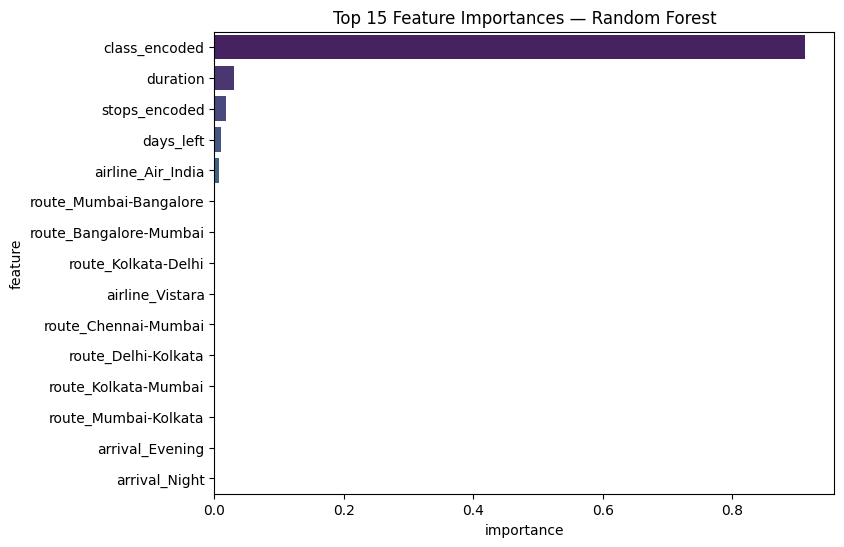

In [136]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(15))

plt.figure(figsize=(8,6))
sns.barplot(data=importances.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest')
plt.show()

Random Forest feature importance confirms class_encoded as the dominant predictor (importance ~0.90), far outweighing all other features. This validates the EDA finding (Phase 6) of a ~7x price gap between Business and Economy. It also resolves the earlier Lasso/Ridge coefficient confusion: the negative class_encoded coefficient in the linear models was an artifact of multicollinearity with airline/route dummies, not a reflection of class's true importance. Tree-based feature importance, being based on split-quality contribution rather than correlated linear coefficients, is more reliable here.

Random Forest outperformed the single Decision Tree (Test R2: 0.9576 vs 0.9457), consistent with the ensemble/averaging effect reducing variance from any single tree's specific splits. The train-test gap widened slightly (0.0096 vs 0.0037), reflecting Random Forest's deeper trees (max_depth=15) fitting training data a bit more closely — still a healthy, non-overfit gap, and will be examined further during hyperparameter tuning.

**Model 6 — Gradient Boosting**


In [137]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=400, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = evaluate_model("Gradient Boosting", gb, X_train, y_train, X_test, y_test)
print(y_pred_gb)

y_pred_train_gb = gb.predict(X_train)
print(f"Train R2: {r2_score(y_train, y_pred_train_gb):.4f}")
print(f"Test R2:  {r2_score(y_test, y_pred_gb):.4f}")

Gradient Boosting -> R2: 0.9644 | MAE: 2494.63 | RMSE: 4287.12
[50700.89660596 54283.93118883 50122.65864755 ...  4840.03009134
  6037.26124404  4509.23909886]
Train R2: 0.9726
Test R2:  0.9644


Gradient Boosting achieved the best performance so far (Test R2: 0.9644, MAE: 2494.69), improving on Random Forest. n_estimators was increased to 400 (from a typical starting point of 100) to allow more sequential correction rounds; combined with the default learning_rate=0.1, this gave the model more opportunity to refine residual errors without any single tree overfitting, since each tree's contribution is shrunk by the learning rate. The train-test gap (0.9726 vs 0.9644) remains small and healthy, indicating this is a real generalization improvement, not overfitting.

**Model 7 — XGBoost (the final model)**

In [138]:

from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=400, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred_xgb = evaluate_model("XGBoost", xgb, X_train, y_train, X_test, y_test)
print(y_pred_xgb)

y_pred_train_xgb = xgb.predict(X_train)
print(f"Train R2: {r2_score(y_train, y_pred_train_xgb):.4f}")
print(f"Test R2:  {r2_score(y_test, y_pred_xgb):.4f}")

XGBoost -> R2: 0.9639 | MAE: 2507.63 | RMSE: 4315.90
[50819.04   54196.08   48877.98   ...  4868.3037  6162.5386  4807.917 ]
Train R2: 0.9714
Test R2:  0.9639


XGBoost (Test R2: 0.9639) performed marginally below Gradient Boosting (Test R2: 0.9644) under identical hyperparameters. This is a small enough difference to be within normal model-to-model variance, and may reflect XGBoost's built-in L1/L2 regularization making it slightly more conservative. Both are very close; final model selection will depend on results after proper hyperparameter tuning (Phase 12), rather than this initial equal-parameter comparison alone.


* ### Model Building Summary
* 7 models trained: Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, XGBoost.

* Best performer (default parameters): Gradient Boosting (Test R2: 0.9644)
Linear models plateaued around R2=0.9086 due to their inability to capture the strong non-linear, threshold-driven price structure (especially the class-based split confirmed dominant by Random Forest's feature importance).
Tree ensemble methods (Random Forest, Gradient Boosting, XGBoost) all substantially outperformed linear models and the single Decision Tree, consistent with theory.
* All models show healthy, small train-test R2 gaps, indicating no severe overfitting at these default settings.

* Next: hyperparameter tuningon the top 3 candidates to see if performance can be meaningfully improved beyond these baselines.

                         R2          MAE         RMSE
Gradient Boosting  0.964378  2494.630488  4287.117677
XGBoost            0.963898  2507.634521  4315.895967
Random Forest      0.957631  2618.914187  4675.508816
Decision Tree      0.945642  3058.573454  5295.863616
Linear Regression  0.908567  4585.661777  6868.408680
Ridge Regression   0.908565  4585.529449  6868.452612
Lasso Regression   0.908555  4581.725228  6868.829673


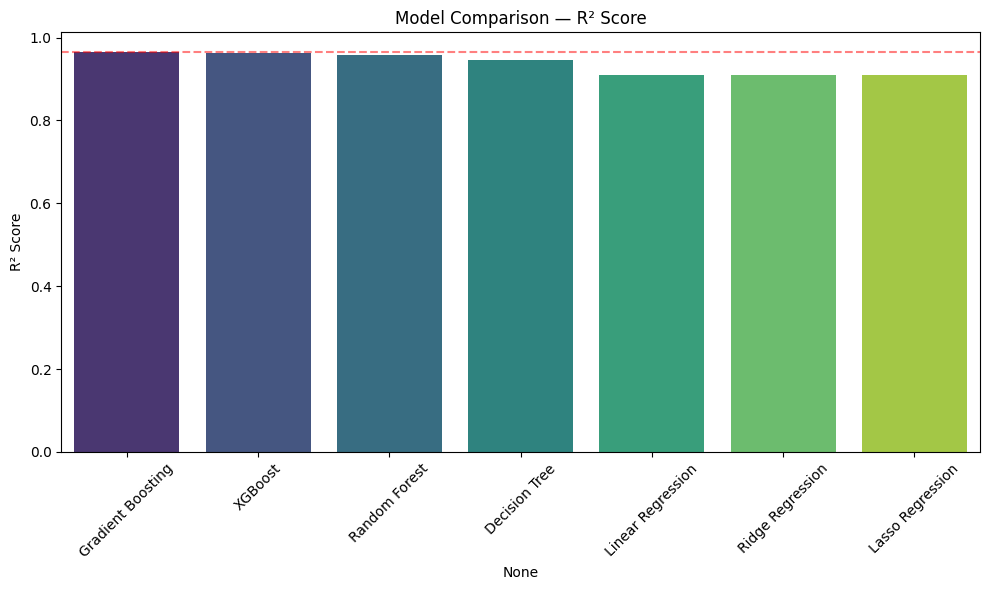

In [139]:
results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print(results_df)

plt.figure(figsize=(10,6))
sns.barplot(x=results_df.index, y=results_df['R2'], palette='viridis')
plt.xticks(rotation=45)
plt.title('Model Comparison — R² Score')
plt.ylabel('R² Score')
plt.axhline(results_df['R2'].max(), color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 12. Hyperparameter Tuning
Models tuned: Ridge, Random Forest, XGBoost

**Ridge Hyperparameter Tuning**
* **Using GrideSearchCV**

In [140]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]
}

ridge_grid = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=ridge_params,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best alpha:", ridge_grid.best_params_)
print("Best CV R2:", ridge_grid.best_score_)

best_ridge = ridge_grid.best_estimator_
y_pred_ridge_tuned = evaluate_model("Ridge (Tuned)", best_ridge, X_train, y_train, X_test, y_test)

Best alpha: {'alpha': 1}
Best CV R2: 0.909722979228419
Ridge (Tuned) -> R2: 0.9086 | MAE: 4585.53 | RMSE: 6868.45


**Random Forest Tuning**

In [141]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_params,
    n_iter=20,
    cv=kf,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train, y_train)

print("Best params:", rf_random.best_params_)
print("Best CV R2:", rf_random.best_score_)

best_rf = rf_random.best_estimator_
y_pred_rf_tuned = evaluate_model("Random Forest (Tuned)", best_rf, X_train, y_train, X_test, y_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}
Best CV R2: 0.9669518933013437
Random Forest (Tuned) -> R2: 0.9694 | MAE: 2162.00 | RMSE: 3973.61


* **min_samples_split** — the minimum number of training examples a node must have before it's allowed to split further. Higher values = more conservative tree, less overfitting risk.
* **min_samples_leaf** — minimum examples required in a final leaf. Similarly, higher = smoother, less overfit predictions (a leaf's prediction is averaged over more examples).
* **max_features** — how many features are randomly considered at each split . 'sqrt' means considering √51 ≈ 7 features per split — a common default that increases tree diversity.
* **n_iter=20** — RandomizedSearch will try 20 random combinations out of the (4×5×3×3×3=540) possible combinations in this grid — a reasonable budget that balances thoroughness with runtime.

**Tuning XGBoost (RandomizedSearchCV)**

In [142]:
from xgboost import XGBRegressor

xgb_params = {
    'n_estimators': [200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=xgb_params,
    n_iter=20,
    cv=kf,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(X_train, y_train)

print("Best params:", xgb_random.best_params_)
print("Best CV R2:", xgb_random.best_score_)

best_xgb = xgb_random.best_estimator_
y_pred_xgb_tuned = evaluate_model("XGBoost (Tuned)", best_xgb, X_train, y_train, X_test, y_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.15, 'colsample_bytree': 0.9}
Best CV R2: 0.9676242470741272
XGBoost (Tuned) -> R2: 0.9698 | MAE: 2265.23 | RMSE: 3950.25


In [143]:
# submission=pd.DataFrame({'id': np.arange(0,test_data.shape[0]),'target':y_pred_xgb_tuned})

In [144]:
print(test_data.shape)
print(test_data.head())

(10000, 11)
   id    airline   flight     source      departure stops    arrival  \
0   0    Vistara   UK-816  Bangalore        Morning  zero  Afternoon   
1   1  Air_India   AI-440    Chennai  Early_Morning  zero    Morning   
2   2   SpiceJet  SG-8938      Delhi        Evening   one    Evening   
3   3    Vistara   UK-838    Chennai          Night   one    Evening   
4   4  Air_India   AI-429      Delhi        Morning   one    Evening   

  destination     class  duration  days_left  
0       Delhi   Economy      2.67       18.0  
1       Delhi   Economy       NaN        5.0  
2   Bangalore   Economy       NaN       44.0  
3     Kolkata  Business     21.00       26.0  
4      Mumbai  Business      7.25       22.0  


In [145]:
# 1. Handle missing values (using TRAIN statistics, not test's own — no leakage)
test_data['duration'] = test_data['duration'].fillna(train_data['duration'].median())
test_data['days_left'] = test_data['days_left'].fillna(train_data['days_left'].median())
test_data['stops'] = test_data['stops'].fillna(train_data['stops'].mode()[0])
test_data['airline'] = test_data['airline'].fillna('Unknown')
test_data['departure'] = test_data['departure'].fillna('Unknown')

print("Missing values after imputation:")
print(test_data.isnull().sum())

Missing values after imputation:
id             0
airline        0
flight         0
source         0
departure      0
stops          0
arrival        0
destination    0
class          0
duration       0
days_left      0
dtype: int64


In [146]:
# 2. Feature engineering — same steps as Phase 7
test_data['route'] = test_data['source'] + '_' + test_data['destination']

stop_mapping = {'zero': 0, 'one': 1, 'two_or_more': 2}
test_data['stops_encoded'] = test_data['stops'].map(stop_mapping)

def booking_urgency(days):
    if days <= 3:
        return 'last_minute'
    elif days <= 15:
        return 'short_term'
    elif days <= 30:
        return 'medium_term'
    else:
        return 'long_term'
test_data['booking_urgency'] = test_data['days_left'].apply(booking_urgency)

# drop non-predictive / redundant columns (same as Phase 7)
test_data_clean = test_data.drop(columns=['id','flight','source','destination','stops'], errors='ignore')
print(test_data_clean.columns.tolist())

['airline', 'departure', 'arrival', 'class', 'duration', 'days_left', 'route', 'stops_encoded', 'booking_urgency']


In [147]:
# 3. Encoding — same steps as Phase 8
test_data_encoded = pd.get_dummies(test_data_clean, columns=['airline','departure','arrival','route'], drop_first=True)

test_data_encoded['class_encoded'] = test_data_clean['class'].map({'Economy': 0, 'Business': 1})

urgency_mapping = {'long_term': 0, 'medium_term': 1, 'short_term': 2, 'last_minute': 3}
test_data_encoded['booking_urgency_encoded'] = test_data_clean['booking_urgency'].map(urgency_mapping)

test_data_encoded = test_data_encoded.drop(columns=['class','booking_urgency'], errors='ignore')

print(test_data_encoded.select_dtypes(include='object').columns.tolist())  # should be empty
print(test_data_encoded.shape)

[]
(10000, 51)


In [148]:
# 4. Column alignment — CRITICAL step
# test_data might not have every route/airline category train_data had (or vice versa)
test_data_encoded = test_data_encoded.reindex(columns=X_train.columns, fill_value=0)
print(test_data_encoded.shape)  # should now be (10000, 51) matching X_train's column count

(10000, 51)


In [149]:
# 5. Scaling — use the SAME already-fitted scaler (transform only, never fit again)
test_data_encoded[numeric_cols_to_scale] = scaler.transform(test_data_encoded[numeric_cols_to_scale])
print(test_data_encoded[numeric_cols_to_scale].describe())

           duration     days_left
count  10000.000000  10000.000000
mean       0.102504      0.007590
std        0.809497      0.648855
min       -1.195294     -1.250000
25%       -0.489412     -0.500000
50%        0.000000      0.000000
75%        0.529412      0.550000
max        3.451765      1.150000


In [150]:
print(test_data_encoded)

      duration  days_left  stops_encoded  airline_Air_India  airline_GO_FIRST  \
0    -0.989412      -0.40              0              False             False   
1     0.000000      -1.05              0               True             False   
2     0.000000       0.90              1              False             False   
3     1.167059       0.00              1              False             False   
4    -0.450588      -0.20              1               True             False   
...        ...        ...            ...                ...               ...   
9995 -0.058824      -0.15              1               True             False   
9996 -0.401176       0.00              1               True             False   
9997 -0.107059      -0.10              1              False             False   
9998  0.657647       1.15              1               True             False   
9999  0.696471      -0.95              1              False             False   

      airline_Indigo  airli

In [151]:
# 6. Predict using your best tuned model
y_pred_final = xgb.predict(test_data_encoded)

# 7. Build submission — check sample_submission.csv column names first!
submission = pd.DataFrame({
    'id': test_data['id'],   
    'price': y_pred_final  
})

submission.to_csv('submission.csv', index=False)
print(submission)
print(submission.shape)

        id         price
0        0   3993.891113
1        1   8280.870117
2        2   5583.581055
3        3  55694.800781
4        4  49902.753906
...    ...           ...
9995  9995   4890.405762
9996  9996   6336.247559
9997  9997  62495.222656
9998  9998  50079.144531
9999  9999  57862.476562

[10000 rows x 2 columns]
(10000, 2)


In [152]:
print(train_data_encoded.select_dtypes(include='object').columns.tolist())

[]
